# NOTE: 
This is a scoping script built by Claude to test a workflow for decomposing alkalinity sources and 
sinks from MIN3P. Proceed with caution! We still need a person to rebuild and verify this. 

# Where the feedstock's alkalinity goes

**A closed budget to decompose ten-year CDR**

Every site in this repo gets the same amendment, which can drive at most 12.3 t/co2/ha.
The eight sites land between **0.28** and **4.44** t CO₂/ha, 
and this notebook accounts for the difference as a sum of named terms:

```
maximum potential CDR
  − feedstock that never dissolved
  − alkalinity eaten by secondary clay (montmorillonite)
  − alkalinity eaten by oxides (gibbsite)
  ± other silicate (K-feldspar, silica)
  ± soil carbonate, relative to the control
  − acidity carried off as dissolved aluminium (the exchange complex, unloading)
  − alkalinity still sitting in the profile
  = actual CDR
```

**Aluminum loss term takes on the residual.** Section 2 closes it to 10⁻¹⁵ t CO₂/ha at every site,
because the aluminium term is *defined* as the closing residual of an alkalinity balance whose other
terms are all measured. Section 3 is the check that matters: that residual is not slop — it tracks
dissolved aluminium leaving the profile at 3.4 equivalents per mole, r² = 0.995, and it is under
0.32 t CO₂/ha in every unamended control.

**Section 4 follows the cations**, which is where the mechanism actually lives. The exchange complex
has a fixed capacity, so the feedstock's Mg²⁺ cannot park on it without displacing something. What
gets displaced decides everything: at the acid sites it is **Al³⁺**, which hydrolyses and eats the
alkalinity; at the carbonate sites it is **Ca²⁺**, which pushes the pore water toward calcite
saturation and shuts down the weathering the control was doing. And at seven of the eight sites
**86–100% of the feedstock's magnesium is still on the exchanger after ten years** — it has not
left the profile at all.

**Three regimes come out of it.** *Acid soils* (Cecil, Kalamazoo, Palouse) dissolve nearly all their
feedstock and then spend 67–90% of the alkalinity on clay and on aluminium — Cecil keeps 4.6% of its
ceiling. *Carbonate soils* (HoustonBlack, Kuma, Pullman, Yolo) lose to a control that was already
weathering carbonate, and at two of them the feedstock barely dissolves. *Flanagan* is neither: it
loses almost everything to gibbsite.

CDR here is the repo's carbonate-corrected metric, identical to `figures/fig4.ipynb` and derived in
`tests/MetForcingResolution100cmFront.ipynb` §0b. The eight numbers this notebook decomposes
reproduce that notebook's to three decimals. `tests/CdrDecomposition-MetForcing.ipynb` runs the same
ladder against the met-forcing question.

## 0. Setup

Two knobs — the reporting plane and the met forcing — and everything below follows from them. The
raw MIN3P output is read directly: `.gsv` (mineral volume fractions vs depth, 42 snapshots), `.gsm`
(alkalinity and pH), `.gsp` (water content), `.gst` (total aqueous component concentrations),
`_o.mss` (the sorbed inventory), and the `.gbp`/`.gbt`/`.gbm` transient monitors at the two control
volumes straddling the plane.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from byte_util.met_transport import calc_specific_discharge
from byte_util.util import states_per_site

# ============================== what to look at ==============================
PLANE = 100          # reporting plane, cm below surface; one of 50, 100, 200, 300
CASE = "hourly"      # met forcing; one of hourly, daily, monthly, longterm
SAVE = False         # write the figures to figures/
# =============================================================================


def _find(name):
    """The derived/raw trees live either beside this notebook or in the download cache."""
    here = Path.cwd()
    for base in (here, here / "tests", here.parent / "tests",
                 Path.home() / ".cache" / "min3p_outputs"):
        if (base / name).is_dir():
            return base / name
    raise FileNotFoundError(f"cannot find {name}/ -- looked beside the notebook and in ~/.cache")


DERIVED, RAW = _find("derived_rxn"), _find("met_forcing_rxn")
VERSION = next(v for v in ("v3", "v2", "v1") if (DERIVED / f"rxn_flux_{v}.parquet").exists())
SITES = sorted(p.name for p in RAW.iterdir() if p.is_dir())

# ------------------------------------------------------------------- palette
# Three colour jobs, kept apart on purpose.
#
# 1. POLARITY, in the ladders: a step either adds CO2 removal or takes it away. That is a diverging
#    encoding, so it gets the diverging pair -- blue for a gain, red for a loss -- and the totals
#    get neutral ink. The step's identity is carried by its axis label, not by its hue.
# 2. IDENTITY OF A SINK, in the synthesis: categorical, so it takes the categorical slots in fixed
#    order, never cycled.
# 3. IDENTITY OF AN ION, in the exchange ledger: categorical again, and deliberately tied to (2) --
#    Al(3+) wears the same magenta as the `dissolved Al` bar and Ca(2+) the same yellow as the
#    `soil carbonate` bar, because which ion comes off the exchanger is what decides which bar the
#    site loses to. That correspondence is the point of the section, so the colour carries it.
#
# `site` keeps the hue it has in the sibling notebooks, and is used only where a site is a series.
GAIN, LOSS = "#2a78d6", "#e34948"
INK, MUTED, RULE = "#1a1a1a", "#5c5c5c", "#b8b7b2"
SINK_COLOR = {                       # categorical slots 1-6, fixed order
    "feedstock undissolved": "#2a78d6",
    "montmorillonite":       "#eb6834",
    "gibbsite":              "#1baf7a",
    "soil carbonate":        "#eda100",
    "dissolved Al":          "#e87ba4",
    "other":                 "#008300",
}
ION_COLOR = {"Mg$^{2+}$": "#2a78d6", "Ca$^{2+}$": "#eda100", "Al$^{3+}$": "#e87ba4",
             "Na$^+$, K$^+$, H$^+$": "#1baf7a"}
SITE_COLOR = {"Yolo": "#e34948", "Pullman": "#4a3aa7", "Palouse": "#008300",
              "HoustonBlack": "#1baf7a", "Kuma": "#eda100", "Flanagan": "#a24fc0",
              "Cecil": "#0d8bb5", "Kalamazoo": "#8a6d3b"}

plt.rcParams.update({
    "figure.dpi": 120, "axes.grid": False,
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
    "lines.linewidth": 1.8, "legend.frameon": False, "font.size": 9.5,
    "axes.titlesize": 10.5, "figure.titlesize": 12, "axes.edgecolor": "#8a8a85",
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "axes.labelcolor": INK, "figure.facecolor": "white",
})

print(f"tables {VERSION} from {DERIVED}")
print(f"raw    from {RAW}")
print(f"{len(SITES)} sites, plane {PLANE} cm, {CASE} forcing")
print("  " + ", ".join(f"{s} ({states_per_site[s]})" for s in SITES))

tables v3 from /Users/tylerkukla/Github/min3p-model-bytes/tests/derived_rxn
raw    from /Users/tylerkukla/Github/min3p-model-bytes/tests/met_forcing_rxn
8 sites, plane 100 cm, hourly forcing
  Cecil (Northern SC), Flanagan (Central IL), HoustonBlack (Central TX), Kalamazoo (Central MI), Kuma (Eastern CO), Palouse (Eastern WA), Pullman (Northern TX), Yolo (Central CA)


In [2]:
# ------------------------------------------------------------------ spatial files
def read_tecplot(path, header_lines=3):
    """A MIN3P spatial file: `variables = "..."` on line 2, data after the zone line."""
    head = open(path).readlines()[:header_lines]
    names = [n.strip() for n in re.findall(r'"([^"]*)"', head[1])]
    arr = pd.read_csv(path, sep=r"\s+", skiprows=header_lines, header=None).to_numpy()
    return names, arr


def depth_and_dz(arr):
    """Depth below the surface in cm, and the control-volume thickness in m."""
    z = arr[:, 2]
    return (z.max() - z) * 100.0, np.abs(np.gradient(z))


def snapshots(site, case, treat, ext):
    """First and last spatial snapshot of one run, for one file family."""
    folder = RAW / site / f"{case}_{treat}"
    files = sorted(folder.glob(f"{case}_*.{ext}"), key=lambda p: int(p.stem.split("_")[-1]))
    if not files:
        raise FileNotFoundError(f"no .{ext} in {folder}")
    names, first = read_tecplot(files[0])
    _, last = read_tecplot(files[-1])
    return names, first, last


# ------------------------------------------------------------------ transient monitors
# The monitor index does not encode depth -- MIN3P writes the control volume into the zone line,
# and on this 401-cell, 1 cm grid control volume n sits at depth (401 - n) cm. So the depth is read
# out of each file rather than assumed, and only the two files the plane needs are ever loaded.
def _monitor_head(path):
    """Variable names (they wrap), the control volume, and how many lines to skip."""
    head = []
    with open(path, errors="replace") as fh:
        for _ in range(12):
            line = fh.readline()
            if not line:
                break
            head.append(line)
            if line.lstrip().lower().startswith("zone"):
                break
    v0 = next(i for i, ln in enumerate(head) if ln.lstrip().lower().startswith("variables"))
    names = [n.strip() for n in re.findall(r'"([^"]*)"', "".join(head[v0:-1]))]
    return names, int(re.search(r"volume\s*=\s*(\d+)", head[-1]).group(1)), len(head)


def monitor(folder, case, ext, depth):
    """The one `.gb*` monitor of a family that sits at `depth` cm."""
    for path in sorted(Path(folder).glob(f"{case}_*.{ext}")):
        names, volume, skip = _monitor_head(path)
        if 401 - volume == depth:
            return names, pd.read_csv(path, sep=r"\s+", skiprows=skip, header=None).to_numpy()
    raise FileNotFoundError(f"no .{ext} monitor at {depth} cm in {folder}")


def dedupe(t, f):
    """MIN3P writes a duplicate record whenever it lands exactly on a forced output time."""
    keep = np.concatenate([[True], np.diff(t) > 0])
    return t[keep], f[keep]


def cumtrap(t, f):
    """Trapezoidal running integral of an irregularly sampled rate."""
    out = np.zeros_like(f, dtype=float)
    out[1:] = np.cumsum(0.5 * (f[1:] + f[:-1]) * np.diff(t))
    return out


# Every cation the exchange ledger needs, the aluminium the residual turns out to be, and the
# chloride that closes the conservative-ion charge balance of section 3b.
EXPORT_SPECIES = ("al+3", "mg+2", "ca+2", "na+1", "k+1", "cl-1")
# Charge on each conservative ion, for the charge-balance alkalinity
#     ANC = 2[Mg] + 2[Ca] + [Na] + [K] - [Cl]
# which is conserved by every homogeneous reaction and so cannot hide an alkalinity sink.
ANC_CHARGE = {"mg+2": 2, "ca+2": 2, "na+1": 1, "k+1": 1, "cl-1": -1}


def plane_export(site, case, treat, plane):
    """Ten-year cumulative export across a control plane. Downward is positive.

    MIN3P writes no flux at depth, so the specific discharge is rebuilt from the head difference
    across the cell pair straddling the plane, using the deck's van Genuchten parameters and
    MIN3P's own harmonic interface conductivity with upstream relative permeability
    (`byte_util.met_transport`, validated to 0.21% against MIN3P's `.vel` output in
    `MetForcingResolutionTransport.ipynb`). The upstream cell's concentration is carried across
    the interface, matching MIN3P's upstream spatial weighting.
    """
    folder = RAW / site / f"{case}_{treat}"
    pcols, p_up = monitor(folder, case, "gbp", plane)
    _, p_dn = monitor(folder, case, "gbp", plane + 1)
    tcols, t_up = monitor(folder, case, "gbt", plane)
    _, t_dn = monitor(folder, case, "gbt", plane + 1)
    mcols, m_up = monitor(folder, case, "gbm", plane)
    _, m_dn = monitor(folder, case, "gbm", plane + 1)

    q = -calc_specific_discharge(np.stack([p_up.T, p_dn.T]), input_file=str(folder / f"{case}.dat"),
                                 ci_a=0, ci_b=1, elev_a=4.00 - plane / 100,
                                 elev_b=3.99 - plane / 100, gbp_cols=pcols)   # m/d, positive down
    t = p_up[:, pcols.index("time")]
    upstream = p_up[:, pcols.index("h_w")] > p_dn[:, pcols.index("h_w")]

    def carried(names, up, dn, col):
        # `.gbt`/`.gbm` carry a t = 0 row that `.gbp` does not.
        return np.where(upstream, up[1:, names.index(col)], dn[1:, names.index(col)])

    out = {}
    for sp in EXPORT_SPECIES:
        td, rate = dedupe(t, q * carried(tcols, t_up, t_dn, sp) * 1000)    # mol/m2/d
        out[sp] = float(cumtrap(td, rate)[-1])
    td, rate = dedupe(t, q * carried(mcols, m_up, m_dn, "Alk [eq/L]") * 1000)   # eq/m2/d
    out["alk"] = float(cumtrap(td, rate)[-1])
    td, rate = dedupe(t, q)
    out["drain"] = float(cumtrap(td, rate)[-1])                            # m
    return out


# ------------------------------------------------------------------ the exchange complex
# MIN3P's own domain-integrated sorbed inventory, in moles, with the charge each species carries.
# `mg-x(na)` is one mole of Mg on the exchanger at 2 eq; `al-x(na)` one mole of Al at 3 eq. See
# `simulations/databases/sorption.dbs`.
SORBED = {"mg-x(na)": ("mg", 2), "ca-x(na)": ("ca", 2), "na-x(na)": ("na", 1),
          "k-x(na)":  ("k",  1), "h-x(na)":  ("h",  1), "al-x(na)": ("al", 3)}
ION_CHARGE = {ion: z for ion, z in SORBED.values()}


def sorbed_change(site, case, treat):
    """Ten-year change in every sorbed species, mol/m2. Positive = onto the exchanger."""
    path = RAW / site / f"{case}_{treat}" / f"{case}_o.mss"
    head = open(path).readlines()[:3]
    names = [n.strip() for n in re.findall(r'"([^"]*)"', head[1])]
    arr = pd.read_csv(path, sep=r"\s+", skiprows=3, header=None).to_numpy()
    change = dict(zip(names, arr[-1] - arr[0]))
    return {ion: change[k] for k, (ion, _) in SORBED.items()}


print("readers ready")

readers ready


## 0b. What "CDR" means here

Unchanged from `MetForcingResolution100cmFront.ipynb` §0b, restated because every number below
rests on it.

CDR is **cumulative alkalinity crossing the reporting plane, corrected for the carbon that came out
of the soil's own carbonate rather than out of the air**, differenced between the amended and
unamended columns:

$$\mathrm{CDR} = \bigl(A_{\rm ERW} - n^{\rm calcite}_{\rm ERW}\bigr) - \bigl(A_{\rm CTRL} - n^{\rm calcite}_{\rm CTRL}\bigr) \qquad [\mathrm{mol\ CO_2/m^2}]$$

with $A$ the exported alkalinity (eq/m²) and $n^{\rm calcite}$ the calcite dissolved above the plane
(mol/m², signed). Weathering by carbonic acid makes alkalinity and consumes CO₂, but not at the
same ratio for every mineral:

| reaction | alkalinity | CO₂ consumed | CO₂ per eq |
|---|---|---|---|
| Mg₂SiO₄ + 4CO₂ + 4H₂O → 2Mg²⁺ + 4HCO₃⁻ + H₄SiO₄ | 4 eq | 4 mol | **1.0** |
| CaCO₃ + CO₂ + H₂O → Ca²⁺ + 2HCO₃⁻ | 2 eq | 1 mol | **0.5** |

One of the two bicarbonates leaving a dissolving calcite grain carries carbon that was already in
the soil as a solid. Summing over every mineral in the deck, everything except calcite cancels, so
the whole correction is **one mole of CO₂ per mole of calcite dissolved** — signed, so a run that
*precipitates* calcite gets CO₂ back. Without it three of these eight sites get the wrong sign.

Every mineral's alkalinity coefficient below is its own `h+1` stoichiometry in
`simulations/databases/mineral.dbs` — dissolution consumes that many protons, and every proton
consumed comes from carbonic acid. Calcite is written on the `co3-2` component instead, and its one
Ca²⁺ carries 2 eq. Two phases carry no alkalinity and are checked rather than assumed: quartz and
`sio2(a,pt)` have no `h+1` term, and `co2_resp` — the deck's respiration source — is written
`co2_resp + H₂O → CO₃²⁻ + 2H⁺`, which is carbonic acid, alkalinity-neutral by construction.

## 1. The decomposition, and why it is an identity

Above the plane, over the run, per m², for one column:

$$\underbrace{\textstyle\sum_m \alpha_m n_m}_{G,\ \text{alkalinity generated}} \;+\; E \;=\; \underbrace{A}_{\text{exported}} \;+\; \underbrace{S}_{\text{stored in solution}}$$

$G$, $A$ and $S$ are all measured — $G$ from the `.gsv` mineral snapshots, $A$ from the
reconstructed plane flux, $S$ from `.gsm` alkalinity times `.gsp` water content. **$E$ is whatever
is left**, so the balance closes by construction. It is not a fudge: §3 shows $E$ is dissolved
aluminium leaving the profile, and that it is negligible in every control.

Rearranged, differenced between the two columns ($\Delta x \equiv x_{\rm ERW} - x_{\rm CTRL}$), and
with the carbonate correction applied to both legs:

$$\mathrm{CDR} \;=\; \underbrace{4 n^{\rm forst}}_{\text{feedstock}} \;+\; \underbrace{1\cdot\Delta n^{\rm calcite}}_{\text{carbonate, corrected}} \;+\; 6\,\Delta n^{\rm mont} \;+\; 3\,\Delta n^{\rm gibb} \;+\; 4\,\Delta n^{\rm kfeld} \;-\; \Delta E \;-\; \Delta S$$

The 2 eq of calcite alkalinity minus the 1 mol of mineral carbon leaves **1 mol CO₂ per mole of
calcite dissolved** — that is where the corrected carbonate coefficient comes from. The control has
no forsterite, so $\Delta n^{\rm forst} = n^{\rm forst}_{\rm ERW}$, which splits into the ceiling
and what never reacted:

$$4 n^{\rm forst}_{\rm ERW} \;=\; \underbrace{4 N_{\rm applied}}_{\text{maximum potential}} \;-\; \underbrace{4\,(N_{\rm applied} - n^{\rm forst}_{\rm ERW})}_{\text{never dissolved}}$$

That is the ladder. Every term is a measured quantity; the sum is the actual CDR to machine
precision.

**One assumption is inherited from §0b** and is worth naming again: the alkalinity term is a flux
*past* the plane, while the carbonate term is calcite dissolved *above* it, so equating the two
assumes the mineral carbon released above the plane has crossed it. §0b of the sibling notebook
checks this (export efficiency 0.96–1.03 wherever the correction is non-zero) and bounds the
exception.

In [3]:
EQ_TO_T_CO2_HA = 44.01e-6 * 1e4       # eq/m2 -> t CO2/ha at 1 mol CO2 per eq, and mol CO2/m2 -> t/ha

# Every mineral in these decks: g/mol, g/cm3, and eq of alkalinity generated per mole dissolved.
MINERALS = {
    "forst-ph":    (140.6931, 3.2000, 4.0),
    "calcite-ph":  (100.0894, 2.7100, 2.0),
    "k-feld-d-ph": (278.3315, 2.5700, 4.0),
    "na-montmor":  (367.2200, 2.7410, 6.0),
    "gibbsite-ph": ( 78.0037, 2.3500, 3.0),
    "quartz":      ( 60.0848, 2.6500, 0.0),
    "sio2(a,pt)":  ( 60.0848, 2.6500, 0.0),
}
MOLAR_VOLUME = {m: gfw / rho * 1e-6 for m, (gfw, rho, _) in MINERALS.items()}
ALK_PER_MOL = {m: a for m, (_, _, a) in MINERALS.items()}
CARBON_MINERAL = "calcite-ph"          # the only phase that carries carbon in or out of the solid

# Moles of a cation released per mole of each phase dissolved, from `mineral.dbs`. Aluminium is
# used in section 3 to say what the residual is; magnesium in section 4 to follow the feedstock.
AL_PER_MOL = {"gibbsite-ph": 1.0, "na-montmor": 1.66, "k-feld-d-ph": 1.0}
MG_PER_MOL = {"forst-ph": 2.0, "na-montmor": 0.34}


def run_terms(site, case, treat, plane):
    """Every measured quantity one run contributes to the budget, above the plane, over ten years.

    Moles dissolved are positive, precipitated negative. `E` is the closing residual of the
    alkalinity balance -- generated, minus exported, minus the change in solution storage.
    """
    names, first, last = snapshots(site, case, treat, "gsv")
    depth, dz = depth_and_dz(first)
    band = depth <= plane

    mols = {m: float((((first[:, names.index(m)] - last[:, names.index(m)]) * dz)[band]).sum()
                     / MOLAR_VOLUME[m]) for m in MINERALS}
    applied = float(((first[:, names.index("forst-ph")] * dz)[band]).sum()
                    / MOLAR_VOLUME["forst-ph"])

    # `theta_a` is the volumetric WATER content (MIN3P's naming; `s_w` is water saturation and the
    # `.gsv` porosity is the reactive one, which the flow solver does not use). Checked below.
    tcols, t0, t1 = snapshots(site, case, treat, "gst")
    qcols, q0, q1 = snapshots(site, case, treat, "gsp")
    mcols, m0, m1 = snapshots(site, case, treat, "gsm")
    th0, th1 = q0[:, qcols.index("theta_a")], q1[:, qcols.index("theta_a")]

    def stored(col0, col1):
        """Change in an aqueous inventory above the plane, mol (or eq) per m2."""
        return float((((col1 * th1 - col0 * th0) * dz)[band]).sum() * 1000)

    S = stored(m0[:, mcols.index("Alk [eq/L]")], m1[:, mcols.index("Alk [eq/L]")])
    ex = plane_export(site, case, treat, plane)
    G = sum(ALK_PER_MOL[m] * mols[m] for m in MINERALS)

    row = {"site": site, "case": case, "treat": treat, "applied": applied,
           "alk_generated": G, "alk_exported": ex["alk"], "alk_stored": S,
           "E": G - ex["alk"] - S, "drain": ex["drain"]}
    for sp in EXPORT_SPECIES:
        row[f"exp_{sp}"] = ex[sp]
        row[f"aq_{sp}"] = stored(t0[:, tcols.index(sp)], t1[:, tcols.index(sp)])
    row["al_out"] = row["aq_al+3"] + row["exp_al+3"]
    row["al_from_minerals"] = sum(c * mols[m] for m, c in AL_PER_MOL.items())
    row["al_displaced"] = row["al_out"] - row["al_from_minerals"]
    row["mg_released"] = sum(c * mols[m] for m, c in MG_PER_MOL.items())
    # The charge-balance alkalinity, exported and stored. Section 3b uses it to show what the
    # residual really is; unlike MIN3P's `Alk` it counts no aluminium at all.
    row["anc_exported"] = sum(z * ex[sp] for sp, z in ANC_CHARGE.items())
    row["anc_stored"] = sum(z * row[f"aq_{sp}"] for sp, z in ANC_CHARGE.items())
    # Every mineral's charge-balance contribution: the base-cation charge it releases. This is the
    # `h+1` coefficient less 3 per mole of aluminium, which is the whole difference between the two
    # alkalinities and the reason the residual exists.
    row["anc_generated"] = G - 3.0 * row["al_from_minerals"]

    for ion, mol in sorbed_change(site, case, treat).items():
        row[f"sorb_{ion}"] = mol
        row[f"sorbeq_{ion}"] = mol * ION_CHARGE[ion]
    row.update(mols)
    return row


def build_terms(case, plane):
    """Cached per (case, plane): reading the raw output takes a couple of minutes."""
    cache = DERIVED / f"cdr_budget_{case}_{plane}_{VERSION}.parquet"
    need = {"sorbeq_mg", "sorbeq_al", "exp_ca+2", "aq_mg+2", "exp_cl-1", "anc_exported"}
    if cache.exists():
        df = pd.read_parquet(cache)
        if need <= set(df.columns):
            print(f"terms read from {cache.name}")
            return df.set_index(["site", "case", "treat"])
        print(f"{cache.name} predates the exchange ledger -- rebuilding")
    df = pd.DataFrame([run_terms(s, case, t, plane) for s in SITES for t in ("ctrl", "erw")])
    df.to_parquet(cache, index=False)
    print(f"terms built and cached to {cache.name}")
    return df.set_index(["site", "case", "treat"])


TERMS = build_terms(CASE, PLANE)

pd.set_option("display.width", 200)
display(TERMS.droplevel("case")[
    ["applied", "forst-ph", "calcite-ph", "na-montmor", "gibbsite-ph", "k-feld-d-ph",
     "alk_generated", "alk_exported", "alk_stored", "E"]].round(3))

cdr_budget_hourly_100_v3.parquet predates the exchange ledger -- rebuilding


terms built and cached to cdr_budget_hourly_100_v3.parquet


applied  forst-ph  calcite-ph  na-montmor  gibbsite-ph  k-feld-d-ph  alk_generated  alk_exported  alk_stored       E
site         treat                                                                                                                      
Cecil        ctrl     0.000     0.000       0.000       0.098       -0.008        0.004          0.580         0.530      -0.018   0.068
             erw      6.989     6.602       0.000      -1.673       -0.344        0.023         15.430         1.804       0.032  13.595
Flanagan     ctrl     0.000     0.000       8.506       0.261       -0.004        0.023         18.657        18.896      -0.144  -0.094
             erw      6.989     6.625       6.855      -1.508       -3.932        0.009         19.404        19.519      -0.059  -0.057
HoustonBlack ctrl     0.000     0.000      13.225       0.020       -0.020        0.057         26.738        27.096      -0.581   0.223
             erw      6.989     5.351       1.961      -0.024        0.000        0.005         25.203        25.913      -0.586  -0.124
Kalamazoo    ctrl     0.000     0.000       0.000       0.081       -0.013        0.002          0.453         0.225      -0.004   0.232
             erw      6.989     6.918       0.000      -1.722       -0.672        0.000         15.326         0.859       0.017  14.450
Kuma         ctrl     0.000     0.000       3.800       0.056       -0.006        0.003          7.931         7.836      -0.122   0.217
             erw      6.989     4.047      -1.378      -0.517       -0.036        0.000         10.226         8.580       0.046   1.601
Palouse      ctrl     0.000     0.000       0.000       0.293       -0.000        0.005          1.776         2.509      -0.019  -0.714
             erw      6.989     5.997       0.000      -1.479       -0.022        0.002         15.059         7.520       0.165   7.375
Pullman      ctrl     0.000     0.000       3.232       0.036       -0.012        0.004          6.662         6.378      -0.201   0.484
             erw      6.989     3.223      -3.141      -0.296       -0.009        0.001          4.813         4.760      -0.237   0.290
Yolo         ctrl     0.000     0.000       5.673       0.138       -0.001        0.026         12.277        12.317      -0.071   0.031
             erw      6.989     5.277       2.784      -1.161       -0.022        0.015         19.704        14.124       0.107   5.472

In [4]:
# ------------------------------------------------------------------ four checks on the inputs
# 1. The exported alkalinity rebuilt here must reproduce the repo's cached flux table, which is
#    what fig4 and the sibling notebooks draw. Anything else means the flux reconstruction drifted.
flux = pd.read_parquet(DERIVED / f"rxn_flux_{VERSION}.parquet",
                       columns=["site", "case", "treat", "day", f"alk_{PLANE}"])
END = flux["day"].max()
cached = (flux[(flux.day == END) & (flux.case == CASE)]
          .set_index(["site", "treat"])[f"alk_{PLANE}"])
gap = (TERMS["alk_exported"].to_numpy()
       - cached.reindex(TERMS.droplevel("case").index).to_numpy())
gap = np.abs(gap).max()
assert gap < 0.05, f"rebuilt alkalinity export disagrees with rxn_flux_{VERSION} by {gap:.3f} eq/m2"
print(f"alkalinity export matches rxn_flux_{VERSION} to {gap:.4f} eq/m2 "
      f"(the table is on a daily grid, this is on the native one)")

# 2. `theta_a` really is the water content: theta_a / s_w must equal the FLOW porosity, which is
#    the deck's value less the volume the minerals occupy -- not the `.gsv` reactive porosity.
names, first, _ = snapshots(SITES[0], CASE, "erw", "gsv")
qcols, q0, _ = snapshots(SITES[0], CASE, "erw", "gsp")
ratio = q0[:, qcols.index("theta_a")] / q0[:, qcols.index("s_w")]
print(f"theta_a / s_w spans {ratio.min():.4f}-{ratio.max():.4f} -- the two flow porosities in the "
      f"deck, not the reactive porosity ({first[:, names.index('porosity')].min():.3f}-"
      f"{first[:, names.index('porosity')].max():.3f})")

# 3. The exchanger's charge is fixed by the CEC, so every ion that lands on it displaced an
#    equivalent of something else. Section 4 leans on this; if it drifts, `_o.mss` is misread.
charge = sum(TERMS[f"sorbeq_{i}"] for i in ION_CHARGE)
assert charge.abs().max() < 0.1, f"exchanger charge is not conserved ({charge.abs().max():.3f})"
print(f"exchanger charge conserved to {charge.abs().max():.3f} eq/m2 across all {len(TERMS)} legs")

# 4. Every site gets the same amendment, and the control has no forsterite at all.
applied = TERMS.xs("erw", level="treat")["applied"]
assert np.allclose(applied, applied.iloc[0], rtol=1e-9), "sites do not share one application rate"
assert np.allclose(TERMS.xs("ctrl", level="treat")["forst-ph"], 0.0), "a control dissolved forsterite"
N_APPLIED = float(applied.iloc[0])
CEILING = 4.0 * N_APPLIED * EQ_TO_T_CO2_HA
print(f"\nfeedstock: {N_APPLIED:.4f} mol/m2 forsterite "
      f"({N_APPLIED * 140.6931 / 100:.2f} t/ha) at every site, ceiling {CEILING:.3f} t CO2/ha "
      f"({4 * 44.01 / 140.6931:.3f} t CO2 per t rock)")

alkalinity export matches rxn_flux_v3 to 0.0108 eq/m2 (the table is on a daily grid, this is on the native one)
theta_a / s_w spans 0.3800-0.4348 -- the two flow porosities in the deck, not the reactive porosity (0.638-0.639)
exchanger charge conserved to 0.015 eq/m2 across all 16 legs

feedstock: 6.9893 mol/m2 forsterite (9.83 t/ha) at every site, ceiling 12.304 t CO2/ha (1.251 t CO2 per t rock)


## 2. The ladder

`LADDER` is the decomposition of §1, in the order it is drawn. `budget()` is the same arithmetic for
a single column, which is what the left two panels of every site figure show; the ladder is
literally their difference, with the feedstock bar split into its ceiling and its shortfall.

In [5]:
# label -> (mineral, coefficient in mol CO2 per mole dissolved). The calcite coefficient is 2 eq of
# alkalinity minus 1 mol of mineral carbon = 1: the carbonate correction, already applied.
BUDGET_TERMS = [
    ("feedstock (forsterite)", "forst-ph",    4.0),
    ("soil carbonate",         "calcite-ph",  1.0),
    ("montmorillonite",        "na-montmor",  6.0),
    ("gibbsite",               "gibbsite-ph", 3.0),
    ("other silicate",         "k-feld-d-ph", 4.0),
]
LADDER = ["maximum potential", "never dissolved", "montmorillonite", "gibbsite",
          "other silicate", "soil carbonate", "dissolved Al", "not yet exported"]
STEPS = LADDER[1:]                     # the ladder without its anchor -- what a difference keeps


def budget(TERMS, site, case, treat):
    """One column's CO2 export past the plane, as a sum of named terms. t CO2/ha."""
    r = TERMS.loc[(site, case, treat)]
    out = {label: coef * r[mineral] for label, mineral, coef in BUDGET_TERMS}
    out["dissolved Al"] = -r["E"]
    out["not yet exported"] = -r["alk_stored"]
    out = {k: v * EQ_TO_T_CO2_HA for k, v in out.items()}
    out["exported CO2"] = (r["alk_exported"] - r[CARBON_MINERAL]) * EQ_TO_T_CO2_HA
    return out


def ladder(TERMS, site, case):
    """The CDR decomposition. t CO2/ha, and the sum of the steps IS the CDR."""
    e, c = TERMS.loc[(site, case, "erw")], TERMS.loc[(site, case, "ctrl")]
    step = {"maximum potential": 4.0 * e["applied"],
            "never dissolved": -4.0 * (e["applied"] - e["forst-ph"])}
    for label, mineral, coef in BUDGET_TERMS[1:]:
        step[label] = coef * (e[mineral] - c[mineral])
    step["dissolved Al"] = -(e["E"] - c["E"])
    step["not yet exported"] = -(e["alk_stored"] - c["alk_stored"])
    step = {k: v * EQ_TO_T_CO2_HA for k, v in step.items()}
    step["CDR"] = (  (e["alk_exported"] - e[CARBON_MINERAL])
                   - (c["alk_exported"] - c[CARBON_MINERAL])) * EQ_TO_T_CO2_HA
    return step


def ladder_table(TERMS, case):
    """One row per site: the ladder, the CDR, and the closure of the identity."""
    tbl = pd.DataFrame({s: ladder(TERMS, s, case) for s in SITES}).T[LADDER + ["CDR"]]
    tbl["sum of steps"] = tbl[LADDER].sum(axis=1)
    tbl["closure"] = tbl["sum of steps"] - tbl["CDR"]
    return tbl


LAD = ladder_table(TERMS, CASE)
print(f"Ten-year decomposition past {PLANE} cm, {CASE} forcing, t CO2/ha\n")
display(LAD.sort_values("CDR", ascending=False).round(3))

assert LAD["closure"].abs().max() < 1e-9, "the decomposition does not sum to the CDR"
print(f"the eight ladders sum to their own CDR to {LAD['closure'].abs().max():.1e} t CO2/ha\n")

# And the CDR itself must be the number fig4 and MetForcingResolution100cmFront.ipynb report.
print("cross-check against the published metric (MetForcingResolution100cmFront.ipynb 1b):")
for s, v in {"HoustonBlack": 4.44, "Pullman": 2.09, "Palouse": 2.21}.items():
    print(f"  {s:14s} here {LAD.loc[s, 'CDR']:.3f}   published {v:+.2f}")

Ten-year decomposition past 100 cm, hourly forcing, t CO2/ha



,maximum potential,never dissolved,montmorillonite,gibbsite,other silicate,soil carbonate,dissolved Al,not yet exported,CDR,sum of steps,closure
HoustonBlack,12.304,-2.885,-0.116,0.027,-0.091,-4.957,0.153,0.002,4.437,4.437,0.0
Kuma,12.304,-5.180,-1.513,-0.040,-0.004,-2.279,-0.609,-0.074,2.606,2.606,0.0
Palouse,12.304,-1.747,-4.677,-0.029,-0.006,0.000,-3.560,-0.081,2.205,2.205,-0.0
Pullman,12.304,-6.630,-0.876,0.004,-0.006,-2.805,0.086,0.016,2.093,2.093,0.0
Yolo,12.304,-3.014,-3.431,-0.028,-0.019,-1.272,-2.395,-0.078,2.067,2.067,0.0
Flanagan,12.304,-0.641,-4.672,-5.186,-0.024,-0.727,-0.017,-0.038,1.001,1.001,0.0
Cecil,12.304,-0.682,-4.678,-0.443,0.034,0.000,-5.953,-0.022,0.560,0.560,0.0
Kalamazoo,12.304,-0.126,-4.759,-0.869,-0.003,0.000,-6.257,-0.010,0.279,0.279,-0.0


the eight ladders sum to their own CDR to 2.2e-15 t CO2/ha

cross-check against the published metric (MetForcingResolution100cmFront.ipynb 1b):
  HoustonBlack   here 4.437   published +4.44
  Pullman        here 2.093   published +2.09
  Palouse        here 2.205   published +2.21


Read the table by rows. **HoustonBlack** keeps the most (4.44 t CO₂/ha) despite giving 2.89 back to
undissolved feedstock and 4.96 to carbonate, because it has almost no clay or aluminium sink.
**Cecil** and **Kalamazoo** dissolve nearly all their forsterite — 0.68 and 0.13 t CO₂/ha lost to
unreacted grains, among the smallest shortfalls in the set — and then hand over 11.1 and 11.9 to
montmorillonite, gibbsite and aluminium, ending at 0.56 and 0.28. **Pullman** is the opposite
failure: 6.63 t CO₂/ha of feedstock simply never dissolves.

The `never dissolved` and the sink terms are close to independent, which is what makes the ladder
worth drawing — a site can fail at either end, and four of these eight fail at the far end while
three fail at the near one.

## 3. What $E$ is

$E$ is defined as a residual, so it has to be shown to be a quantity rather than an error bar. Two
pieces of evidence.

**It is aluminium — specifically, the aluminium that got away.** Forsterite's Mg²⁺ floods the
exchange complex and displaces the Al³⁺ sitting on it. That swap costs alkalinity immediately and
for a simple reason: **three equivalents of base-cation charge leave solution for every mole of Al³⁺
released**, and base-cation charge is what escorts bicarbonate out of the profile. Nothing about
this waits on hydrolysis — §3b works it out exactly. The displaced Al³⁺ then has two fates, and
**only one of them is already in $G$**:

* it **precipitates inside the profile**, as gibbsite or montmorillonite — and the acid that
  hydrolysis releases is exactly what those minerals' 3 and 6 eq per mole are. $G$ has it.
* it **leaves the profile still dissolved**, carrying its acidity out unexpressed. $G$ counts the
  alkalinity the minerals made but knows nothing about the exchange swap that paid for this ion, so
  this fate is invisible to it — and lands in $E$.

So $E$ is **not** the acid from hydrolysis that happened here; that is in the `gibbsite` and
`montmorillonite` bars. It is the alkalinity spent at the exchange complex on aluminium that left
before hydrolysing.

The regression says so. Across all sixteen legs $E$ is **3.4 equivalents per mole of aluminium
leaving the profile**, r² = 0.995. Against the aluminium that *did* hydrolyse here it has no
relationship at all (r² = −0.28). Flanagan is the clean case: it displaces 6.45 mol/m² of Al, more
than any site but Kalamazoo, precipitates 6.43 of it, and has $E \approx 0$.

**The aluminium came off the exchanger.** The Al balance above the plane — what left, plus what
accumulated in solution, minus what the minerals released — recovers the whole-domain change in
exchangeable Al that MIN3P reports independently in `_o.mss`. The two agree to within 7% at every
site that displaces more than half a mole per square metre — which also says the exchange reaction
is finished well above 1 m. (HoustonBlack's ratio of 0.27 is on 0.03 mol/m², i.e. on nothing.)

**And it is small where it should be.** In every unamended control $|E| \le 0.71$ eq/m²
(0.32 t CO₂/ha) — that is the honest closure error on this budget, and it is the uncertainty to
attach to the `dissolved Al` step.

In [6]:
AL = TERMS.droplevel("case").copy()
AL["al_displaced_domain"] = -AL["sorb_al"]         # positive = displaced off the exchanger

# Regression of E on the aluminium that left, through the origin: E = z * al_out.
x, y = AL["al_out"].to_numpy(), AL["E"].to_numpy()
Z_EFF = float((x * y).sum() / (x * x).sum())
r2 = 1.0 - ((y - Z_EFF * x) ** 2).sum() / ((y - y.mean()) ** 2).sum()

erw = AL.xs("erw", level="treat")
ctl = AL.xs("ctrl", level="treat")
print(f"E = {Z_EFF:.2f} eq per mole of aluminium leaving the profile  (r2 = {r2:.4f}, "
      f"{len(x)} legs)")

# The negative control, and the reason the term is named for aluminium that LEFT. If E were the
# acid released when Al hydrolyses inside the profile, it would track the gibbsite that formed --
# and that acid is already in G, at 3 eq per mole. It does not track it at all.
def _through_origin(col):
    a = AL[col].to_numpy()
    b = float((a * y).sum() / (a * a).sum())
    return b, 1.0 - ((y - b * a) ** 2).sum() / ((y - y.mean()) ** 2).sum()


AL["gibbsite_precipitated"] = -AL["gibbsite-ph"].clip(upper=0)
AL["al_into_minerals"] = -AL["al_from_minerals"]
for col, what in (("al_out", "aluminium that LEFT in solution"),
                  ("gibbsite_precipitated", "gibbsite that FORMED here"),
                  ("al_into_minerals", "aluminium that PRECIPITATED here")):
    b, rr = _through_origin(col)
    print(f"  E vs {what:34s} slope {b:6.2f}   r2 {rr:+.3f}")
print(f"closure in the controls: |E| <= {ctl['E'].abs().max():.2f} eq/m2 "
      f"= {ctl['E'].abs().max() * EQ_TO_T_CO2_HA:.2f} t CO2/ha\n")

check = pd.DataFrame({
    "Al displaced, above plane (mol/m2)": erw["al_displaced"],
    "Al displaced, whole domain (mol/m2)": erw["al_displaced_domain"],
    "ratio": erw["al_displaced"] / erw["al_displaced_domain"],
    "Al exported past plane (mol/m2)": erw["exp_al+3"],
    "E (eq/m2)": erw["E"],
    "dissolved Al step (t CO2/ha)": LAD["dissolved Al"]})
print("Amended runs. The first two columns are independent measurements of the same thing.")
display(check.round(3))

E = 3.42 eq per mole of aluminium leaving the profile  (r2 = 0.9951, 16 legs)
  E vs aluminium that LEFT in solution    slope   3.42   r2 +0.995
  E vs gibbsite that FORMED here          slope   0.91   r2 -0.281
  E vs aluminium that PRECIPITATED here   slope   1.65   r2 +0.240
closure in the controls: |E| <= 0.71 eq/m2 = 0.31 t CO2/ha

Amended runs. The first two columns are independent measurements of the same thing.


,"Al displaced, above plane (mol/m2)","Al displaced, whole domain (mol/m2)",ratio,Al exported past plane (mol/m2),E (eq/m2),dissolved Al step (t CO2/ha)
Cecil,6.951,7.485,0.929,3.825,13.595,-5.953
Flanagan,6.451,6.409,1.006,0.022,-0.057,-0.017
HoustonBlack,0.034,0.126,0.270,0.007,-0.124,0.153
Kalamazoo,7.964,7.684,1.036,4.428,14.450,-6.257
Kuma,1.335,1.308,1.021,0.444,1.601,-0.609
Palouse,4.532,4.492,1.009,2.046,7.375,-3.560
Pullman,0.595,0.578,1.030,0.100,0.290,0.086
Yolo,3.367,3.330,1.011,1.431,5.472,-2.395


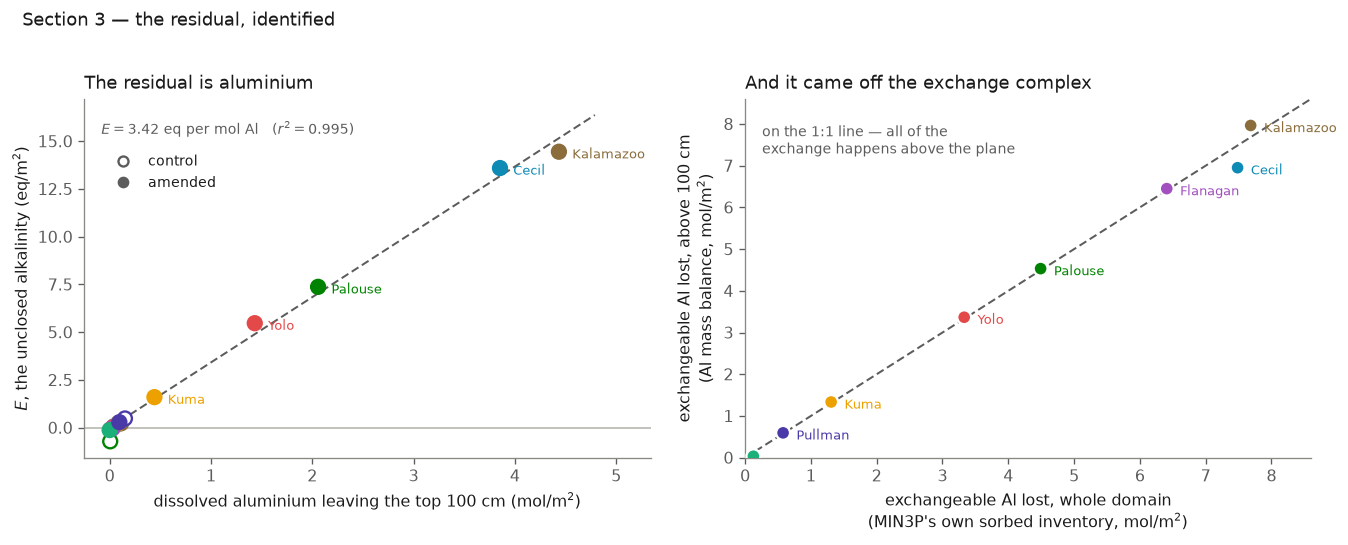

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.4))

# --- left: E against the aluminium that left ---------------------------------
ax = axes[0]
for treat, filled in (("ctrl", False), ("erw", True)):
    sub = AL.xs(treat, level="treat")
    ax.scatter(sub["al_out"], sub["E"], s=70, zorder=3, linewidth=1.4,
               facecolor=[SITE_COLOR[s] for s in sub.index] if filled else "white",
               edgecolor=[SITE_COLOR[s] for s in sub.index])
span = np.array([0, AL["al_out"].max() * 1.08])
ax.plot(span, Z_EFF * span, color=MUTED, lw=1.2, ls=(0, (4, 2)), zorder=1)
for s in erw.index:
    if erw.loc[s, "al_out"] > 0.3:
        ax.annotate(s, (erw.loc[s, "al_out"], erw.loc[s, "E"]), xytext=(8, -4),
                    textcoords="offset points", fontsize=8, color=SITE_COLOR[s])
ax.axhline(0, color=RULE, lw=1.0, zorder=1)
ax.set_xlim(-0.25, span[1] + 0.55)
ax.annotate(f"$E = {Z_EFF:.2f}$ eq per mol Al   ($r^2 = {r2:.3f}$)",
            (0.03, 0.90), xycoords="axes fraction", fontsize=8.5, color=MUTED)
ax.set_xlabel(f"dissolved aluminium leaving the top {PLANE} cm (mol/m$^2$)")
ax.set_ylabel("$E$, the unclosed alkalinity (eq/m$^2$)")
ax.set_title("The residual is aluminium", loc="left")
ax.legend(handles=[Line2D([], [], ls="", marker="o", mfc="white", mec=MUTED, mew=1.4,
                          label="control"),
                   Line2D([], [], ls="", marker="o", color=MUTED, label="amended")],
          loc="upper left", bbox_to_anchor=(0.02, 0.88), fontsize=8.5)

# --- right: the two independent measures of displaced Al ---------------------
ax = axes[1]
ax.scatter(erw["al_displaced_domain"], erw["al_displaced"], s=70, zorder=3, linewidth=1.4,
           facecolor=[SITE_COLOR[s] for s in erw.index], edgecolor="white")
lim = [0, erw["al_displaced_domain"].max() * 1.12]
ax.plot(lim, lim, color=MUTED, lw=1.2, ls=(0, (4, 2)), zorder=1)
ax.annotate("on the 1:1 line — all of the\nexchange happens above the plane",
            (0.03, 0.93), xycoords="axes fraction", va="top", fontsize=8.5, color=MUTED)
for s in erw.index:
    if erw.loc[s, "al_displaced_domain"] > 0.3:
        ax.annotate(s, (erw.loc[s, "al_displaced_domain"], erw.loc[s, "al_displaced"]),
                    xytext=(8, -4), textcoords="offset points", fontsize=8, color=SITE_COLOR[s])
ax.set_xlim(*lim)
ax.set_ylim(*lim)
ax.set_xlabel("exchangeable Al lost, whole domain\n(MIN3P's own sorbed inventory, mol/m$^2$)")
ax.set_ylabel(f"exchangeable Al lost, above {PLANE} cm\n(Al mass balance, mol/m$^2$)")
ax.set_title("And it came off the exchange complex", loc="left")

fig.suptitle("Section 3 — the residual, identified", y=1.02, x=0.02, ha="left", fontsize=11)
plt.tight_layout()
if SAVE:
    fig.savefig(Path("figures") / f"cdr_decomp_residual_{CASE}_{PLANE}.png",
                dpi=300, bbox_inches="tight")

Cecil displaces **7.0 mol/m² of exchangeable Al³⁺** above the plane and exports **3.8 mol/m²** of it
in solution; Kalamazoo 8.0 and 4.4. Those are the two sites whose CDR nearly vanishes, and this is
where it went. Flanagan displaces just as much aluminium — 6.5 mol/m² — but almost none of it
leaves: 3.9 mol/m² of it precipitates as gibbsite and the other 2.5 is built into montmorillonite
(1.51 mol × 1.66 Al per mole), which closes Flanagan's aluminium budget to 0.03 mol/m². That is why
its loss shows up in the `gibbsite` step rather than the `dissolved Al` one — same mechanism,
different exit, and the exit is what decides which bar it lands in.

Two caveats on the aluminium step, both of which cut the same way. It is the *closing* term, so it
also absorbs the budget's numerical error — bounded above by the controls at 0.32 t CO₂/ha, and
Palouse is the worst of them. And a mole of exported Al³⁺ is scored here at whatever MIN3P's
alkalinity convention implies (3.4 eq); whether that acidity is ever expressed downstream depends on
where the aluminium precipitates, which is outside the modelled domain.

### 3b. Why 3 equivalents per mole, and what the number is *not*

The 3.4 is worth pinning down, because the obvious reading of it is wrong. It is **not** MIN3P
debiting the exported water for aluminium's future hydrolysis. It falls out of a charge balance, and
the charge balance is exact.

Alongside MIN3P's `Alk` — which is a carbonate alkalinity — put the **conservative-ion alkalinity**

$$\mathrm{ANC} \;=\; 2[\mathrm{Mg}] + 2[\mathrm{Ca}] + [\mathrm{Na}] + [\mathrm{K}] - [\mathrm{Cl}]$$

built only from ions no homogeneous reaction can create or destroy. Two facts about it:

1. **Each mineral's ANC contribution is its `h+1` coefficient less 3 per mole of aluminium it
   releases** — montmorillonite 6 → 1.02, gibbsite 3 → 0, K-feldspar 4 → 1, forsterite and calcite
   unchanged. So $G = \mathrm{ANC\ generated} + 3\,n^{\rm Al}_{\rm minerals}$ by construction.
2. **The exchanger's charge is fixed**, so the base-cation charge it absorbs equals the acid-cation
   charge it releases: $3\,n^{\rm Al}_{\rm displaced}$ (checked below to 0.01 eq/m²). That charge
   left solution, so it is ANC the profile no longer has to export.

Add them, and every aluminium term collapses into one:

$$G - A_{\rm ANC} - S_{\rm ANC} \;=\; 3\,n^{\rm Al}_{\rm minerals} + 3\,n^{\rm Al}_{\rm displaced} \;=\; 3 \times (\text{aluminium left dissolved or exported})$$

exactly — slope 1.000, r² = 0.9999 below. **That is where the 3 comes from: base-cation charge
parked on the exchange complex, tracked by the aluminium it evicted.** The alkalinity is consumed at
the moment of exchange, not later.

The remaining ~0.4 eq/mole is the gap between the two alkalinities, $A_{\rm ANC} - A$, and it is
small and noisy (0.28–0.98 per mole across the sites). **MIN3P's exported `Alk` is not carrying a
3 eq/mole aluminium debit** — if it were, this column would read ≈ 3.

Which sharpens the caveat in §7. The acid that exported Al³⁺ will make when it finally hydrolyses is
**not booked anywhere in this budget**, and it should not be: the alkalinity was already paid for at
the exchange site. What that aluminium does downstream is a separate charge against a different
water body, and this notebook does not model it.

In [8]:
# The identity of 3b, checked. `anc_generated` is G less 3 per mole of mineral-released aluminium;
# `anc_exported` / `anc_stored` are the conservative-ion alkalinity across the plane and above it.
D = (TERMS.xs(CASE, level="case").xs("erw", level="treat")
     - TERMS.xs(CASE, level="case").xs("ctrl", level="treat"))

# Charge conservation on the exchanger: base cations in == acid cations out.
base_in = sum(D[f"sorbeq_{i}"] for i in ("mg", "ca", "na", "k"))
acid_out = -sum(D[f"sorbeq_{i}"] for i in ("al", "h"))
print(f"exchanger: base-cation charge absorbed equals acid-cation charge released to "
      f"{(base_in - acid_out).abs().max():.3f} eq/m2\n")

anc = pd.DataFrame({
    "3 x Al left dissolved": 3 * D["al_out"],
    "G - ANC exported - ANC stored": D["anc_generated"] + 3 * D["al_from_minerals"]
                                     - D["anc_exported"] - D["anc_stored"],
    "ANC consumed by the exchanger": base_in,
    "ANC exported - Alk exported": D["anc_exported"] - D["alk_exported"],
    "E (eq/m2)": D["E"]})
anc["per mole of Al exported"] = anc["ANC exported - Alk exported"] / D["exp_al+3"]
display(anc.round(2))

for lhs, rhs in (("G - ANC exported - ANC stored", "3 x Al left dissolved"),
                 ("E (eq/m2)", "3 x Al left dissolved")):
    xx, yy = anc[rhs].to_numpy(), anc[lhs].to_numpy()
    sl = (xx * yy).sum() / (xx * xx).sum()
    rr = 1 - ((yy - sl * xx) ** 2).sum() / ((yy - yy.mean()) ** 2).sum()
    print(f"{lhs:32s} = {sl:.3f} x ({rhs}),  r2 = {rr:.4f}")
print("\nThe first is an identity and lands on 1.000. The second is the same thing plus the\n"
      "carbonate-vs-charge-balance gap, which is what lifts 3.00 to 3.42.")

exchanger: base-cation charge absorbed equals acid-cation charge released to 0.011 eq/m2



,3 x Al left dissolved,G - ANC exported - ANC stored,ANC consumed by the exchanger,ANC exported - Alk exported,E (eq/m2),per mole of Al exported
site,,,,,,
Cecil,11.43,11.40,22.66,2.11,13.53,0.56
Flanagan,0.06,0.02,20.62,0.01,0.04,0.75
HoustonBlack,-0.30,-0.28,0.08,-0.06,-0.35,0.65
Kalamazoo,12.96,12.98,23.14,1.23,14.22,0.29
Kuma,1.08,1.03,3.98,0.36,1.38,0.98
Palouse,6.16,6.25,14.95,1.83,8.09,0.90
Pullman,-0.17,-0.18,1.48,-0.01,-0.19,0.28
Yolo,4.20,4.13,10.70,1.32,5.44,0.94


G - ANC exported - ANC stored    = 1.000 x (3 x Al left dissolved),  r2 = 0.9999
E (eq/m2)                        = 1.162 x (3 x Al left dissolved),  r2 = 0.9924

The first is an identity and lands on 1.000. The second is the same thing plus the
carbonate-vs-charge-balance gap, which is what lifts 3.00 to 3.42.


## 4. The exchange ledger

The exchange complex has a **fixed** capacity — the deck sets a CEC per zone and MIN3P holds it —
so nothing lands on it without something else coming off. That makes it a strict zero-sum ledger,
and it is worth reading as one, because **which ion comes off is what decides which bar of the
ladder the site loses to**.

Two quantities, both taken from MIN3P's own domain-integrated sorbed inventory (`_o.mss`) and both
differenced against the control, so the rainfall input — identical in the two legs, since drainage
matches to within 0.003 m — cancels exactly:

* **feedstock-derived cations lost from solution**: the Mg²⁺ that leaves the pore water and parks
  on an exchange site. Forsterite is the only Mg source the amendment adds, so in the ERW − CTRL
  difference this is feedstock magnesium by construction.
* **exchange-derived cations gained by solution**: the Al³⁺, Ca²⁺, K⁺, Na⁺ and H⁺ that were
  displaced to make room for it.

They balance to under 0.02 eq/m² at every site, which is the check that the ledger is being read
correctly rather than an assumption imposed on it.

Section 3 showed the Al³⁺ half of this. The ledger shows the other half, which section 3 missed:
at the **carbonate** sites the feedstock displaces **Ca²⁺**, not aluminium — and Ca²⁺ entering the
pore water is exactly what pushes it toward calcite saturation and shuts down the carbonate
weathering the control was doing. The `soil carbonate` bar and the `dissolved Al` bar are the two
exits from the same swap.

In [9]:
# Al(3+) wears the `dissolved Al` bar's magenta and Ca(2+) the `soil carbonate` bar's yellow: the
# whole point of this section is that the ion and the bar are the same fact. Na, K and H are
# grouped -- H never exceeds 0.02 eq/m2, and the group keeps the palette inside its validated
# adjacent pairs.
IONS = [("Mg$^{2+}$", ["mg"]), ("Ca$^{2+}$", ["ca"]), ("Al$^{3+}$", ["al"]),
        ("Na$^+$, K$^+$, H$^+$", ["na", "k", "h"])]


def exchange_ledger(TERMS, case):
    """Charge moved on to (+) and off (-) the exchange complex by the amendment. eq/m2, ERW-CTRL."""
    d = TERMS.xs(case, level="case").xs("erw", level="treat") - \
        TERMS.xs(case, level="case").xs("ctrl", level="treat")
    led = pd.DataFrame({name: sum(d[f"sorbeq_{i}"] for i in ions) for name, ions in IONS})
    led["net"] = led.sum(axis=1)
    return led


def magnesium_fate(TERMS, case):
    """Where the feedstock's magnesium is after ten years. mol/m2, ERW-CTRL."""
    d = TERMS.xs(case, level="case").xs("erw", level="treat") - \
        TERMS.xs(case, level="case").xs("ctrl", level="treat")
    released = 2.0 * d["forst-ph"]                       # Mg the forsterite let go
    fate = pd.DataFrame({
        "into secondary clay": -0.34 * d["na-montmor"],  # montmorillonite takes 0.34 Mg per mole
        "onto the exchanger": d["sorb_mg"],
        "exported past the plane": d["exp_mg+2"],
        "in solution above the plane": d["aq_mg+2"]})
    fate.insert(0, "released by the feedstock", released)
    fate["unaccounted"] = released - fate.iloc[:, 1:].sum(axis=1)
    return fate


LEDGER = exchange_ledger(TERMS, CASE)
FATE = magnesium_fate(TERMS, CASE)
ORDER = list(LAD["CDR"].sort_values(ascending=False).index)

assert LEDGER["net"].abs().max() < 0.05, "the exchange ledger does not balance"
print(f"the ledger balances to {LEDGER['net'].abs().max():.3f} eq/m2 at every site "
      f"-- the CEC is fixed, so it must\n")
print("Charge the amendment moved across the exchange complex, eq/m2 (+ on to it, - off it)")
display(LEDGER.loc[ORDER].round(2))

FATE = FATE.assign(**{"% still on the exchanger":
                      100 * FATE["onto the exchanger"] / FATE["released by the feedstock"]})
print("\nWhere the feedstock's magnesium is after ten years, mol/m2 (ERW - CTRL)")
display(FATE.loc[ORDER].round(2))
# The Kalamazoo exception in the prose below rests on this: its magnesium does leave, but in
# place of the base cations the control was exporting, so the charge moves and the alkalinity
# does not.
print("\nExtra base-cation export past the plane, mol/m2 (ERW - CTRL)")
D_EXP = (TERMS.xs(CASE, level="case").xs("erw", level="treat")
         - TERMS.xs(CASE, level="case").xs("ctrl", level="treat"))
display(D_EXP[["exp_mg+2", "exp_ca+2", "exp_na+1", "exp_k+1"]].loc[ORDER].round(2))

print(f"unaccounted is at most {FATE['unaccounted'].abs().max():.2f} mol/m2 against "
      f"{FATE['released by the feedstock'].min():.1f}-{FATE['released by the feedstock'].max():.1f} "
      f"released.\nThe rainfall Mg input is identical in the two legs (drainage matches to "
      f"{(TERMS.xs('erw', level='treat')['drain'] - TERMS.xs('ctrl', level='treat')['drain']).abs().max():.4f} m), "
      f"so it cancels and this is closure only.")

the ledger balances to 0.011 eq/m2 at every site -- the CEC is fixed, so it must

Charge the amendment moved across the exchange complex, eq/m2 (+ on to it, - off it)


,Mg$^{2+}$,Ca$^{2+}$,Al$^{3+}$,"Na$^+$, K$^+$, H$^+$",net
site,,,,,
HoustonBlack,21.39,-21.26,-0.09,-0.05,-0.01
Kuma,15.59,-11.26,-3.99,-0.36,-0.01
Palouse,21.59,-5.66,-14.95,-0.99,-0.01
Pullman,12.91,-11.56,-1.47,0.13,0.01
Yolo,18.26,-6.94,-10.69,-0.63,-0.00
Flanagan,24.99,-3.84,-20.61,-0.54,-0.00
Cecil,24.51,-0.86,-22.64,-1.01,0.00
Kalamazoo,7.03,12.79,-23.14,3.32,-0.00



Where the feedstock's magnesium is after ten years, mol/m2 (ERW - CTRL)


,released by the feedstock,into secondary clay,onto the exchanger,exported past the plane,in solution above the plane,unaccounted,% still on the exchanger
site,,,,,,,
HoustonBlack,10.70,0.01,10.69,-0.01,0.04,-0.03,99.93
Kuma,8.09,0.19,7.80,0.08,0.05,-0.03,96.33
Palouse,11.99,0.60,10.80,0.62,0.06,-0.09,90.01
Pullman,6.45,0.11,6.45,-0.12,0.02,-0.01,100.11
Yolo,10.55,0.44,9.13,0.55,0.07,0.36,86.51
Flanagan,13.25,0.60,12.50,0.08,0.06,0.02,94.30
Cecil,13.20,0.60,12.26,0.60,0.07,-0.32,92.82
Kalamazoo,13.84,0.61,3.51,10.76,0.06,-1.11,25.40



Extra base-cation export past the plane, mol/m2 (ERW - CTRL)


,exp_mg+2,exp_ca+2,exp_na+1,exp_k+1
site,,,,
HoustonBlack,-0.01,-0.55,-0.11,-0.02
Kuma,0.08,0.41,0.01,0.09
Palouse,0.62,2.57,-0.27,0.73
Pullman,-0.12,-0.57,-0.13,-0.10
Yolo,0.55,1.04,-0.16,0.11
Flanagan,0.08,0.43,-0.43,0.03
Cecil,0.60,1.01,-0.59,0.77
Kalamazoo,10.76,-7.81,-0.76,-3.27


unaccounted is at most 1.11 mol/m2 against 6.4-13.8 released.
The rainfall Mg input is identical in the two legs (drainage matches to 0.0031 m), so it cancels and this is closure only.


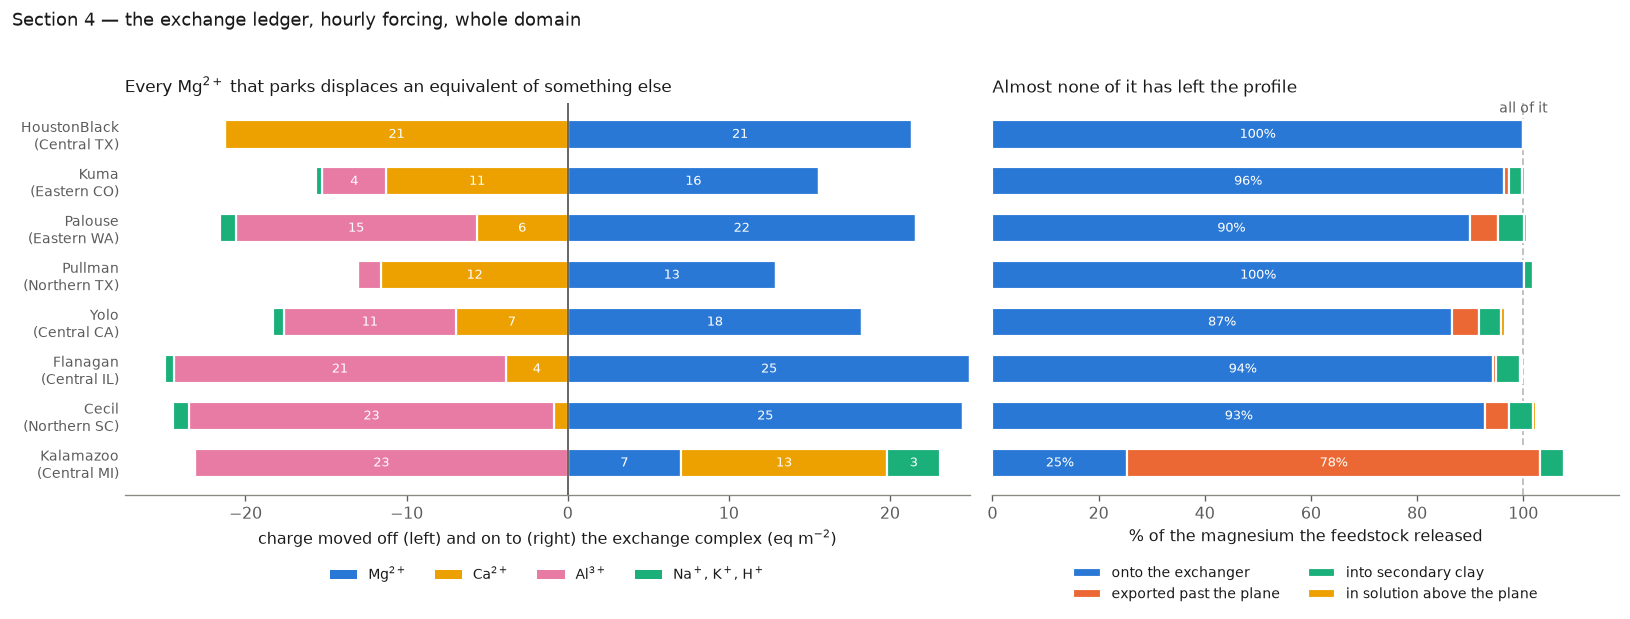

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.1), gridspec_kw={"width_ratios": [1.35, 1]})
y = np.arange(len(ORDER), dtype=float)

# --- left: the zero-sum swap -------------------------------------------------
# Positives stack right from zero, negatives stack left. The two wings are the same length by
# construction, which is the balance check made visible.
ax = axes[0]
labelled = set()
for sign in (+1, -1):
    left = np.zeros(len(ORDER))
    for name, _ in IONS:
        w = np.where(np.sign(LEDGER.loc[ORDER, name].to_numpy()) == sign,
                     LEDGER.loc[ORDER, name].to_numpy(), 0.0)
        if not np.any(w):
            continue
        ax.barh(y, w, left=left, height=0.6, color=ION_COLOR[name], edgecolor="white",
                linewidth=1.3, zorder=3, label=None if name in labelled else name)
        labelled.add(name)
        for yi, wi, li in zip(y, w, left):
            if abs(wi) > 3.0:            # relief rule: these hues need visible labels
                ax.annotate(f"{abs(wi):.0f}", (li + wi / 2, yi), ha="center", va="center",
                            fontsize=7.8, color="white", zorder=5)
        left = left + w
ax.axvline(0, color=MUTED, lw=1.1, zorder=4)
ax.set_yticks(y)
ax.set_yticklabels([f"{s}\n({states_per_site[s]})" for s in ORDER], fontsize=8.6)
ax.invert_yaxis()
ax.set_xlabel("charge moved off (left) and on to (right) the exchange complex (eq m$^{-2}$)")
ax.set_title("Every Mg$^{2+}$ that parks displaces an equivalent of something else", loc="left",
             fontsize=10)
# Legend in IONS order, not in the order the bars happened to be drawn.
ax.legend(handles=[Patch(facecolor=ION_COLOR[n], label=n) for n, _ in IONS],
          loc="upper center", bbox_to_anchor=(0.5, -0.15), ncols=4, fontsize=8.2)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)

# --- right: where the feedstock's magnesium went -----------------------------
ax = axes[1]
FATE_PARTS = [("onto the exchanger", "#2a78d6"), ("exported past the plane", "#eb6834"),
              ("into secondary clay", "#1baf7a"), ("in solution above the plane", "#eda100")]
frac = (FATE.loc[ORDER, [k for k, _ in FATE_PARTS]]
        .div(FATE.loc[ORDER, "released by the feedstock"], axis=0) * 100).clip(lower=0)
left = np.zeros(len(ORDER))
for name, colour in FATE_PARTS:
    w = frac[name].to_numpy()
    ax.barh(y, w, left=left, height=0.6, color=colour, edgecolor="white", linewidth=1.3,
            zorder=3, label=name)
    for yi, wi, li in zip(y, w, left):
        if wi > 8:
            ax.annotate(f"{wi:.0f}%", (li + wi / 2, yi), ha="center", va="center",
                        fontsize=7.8, color="white", zorder=5)
    left = left + w
ax.axvline(100, color=RULE, lw=1.0, ls=(0, (4, 2)), zorder=2)
ax.annotate("all of it", (100, -0.55), ha="center", va="center", fontsize=8.2, color=MUTED)
ax.set_yticks(y)
ax.set_yticklabels([])
ax.invert_yaxis()
ax.set_xlim(0, 118)
ax.set_xlabel("% of the magnesium the feedstock released")
ax.set_title("Almost none of it has left the profile", loc="left", fontsize=10)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncols=2, fontsize=8.2)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)

fig.suptitle(f"Section 4 — the exchange ledger, {CASE} forcing, whole domain",
             y=1.02, x=0.005, ha="left", fontsize=11)
plt.tight_layout()
if SAVE:
    fig.savefig(Path("figures") / f"cdr_decomp_exchange_{CASE}_{PLANE}.png",
                dpi=300, bbox_inches="tight")

The left panel splits the eight sites cleanly in two, and the split is the same one the ladder
found — which is the point, because it was arrived at from a different file.

* **Al³⁺ off** (magenta): Cecil 23, Kalamazoo 23, Flanagan 21, Palouse 15, Yolo 11 eq/m². These are
  exactly the sites whose ladders lose to `montmorillonite`, `gibbsite` and `dissolved Al` — the
  three exits open to a displaced aluminium ion.
* **Ca²⁺ off** (yellow): HoustonBlack 21, Pullman 12, Kuma 11 eq/m². These are the sites whose
  ladders lose to `soil carbonate`. Feedstock Mg²⁺ evicts exchangeable Ca²⁺, the Ca²⁺ enters the
  pore water, and calcite saturation rises — so the amended column dissolves *less* soil carbonate
  than the control does. Yolo sits between the two, with 11 eq of Al and 7 of Ca, and its ladder
  loses to both.
* **Kalamazoo is the odd one.** It is the only site that *gains* Ca²⁺ on the exchanger (+13 eq,
  with +3 more of K⁺) while shedding 23 eq of Al³⁺: its feedstock Mg largely washes through instead
  of sticking, and influent Ca and K take the vacated sites.

The right panel is the blunt version. **At seven of the eight sites, 86–100% of the magnesium the
feedstock released is still sitting on the exchange complex after ten years.** It has not been
exported, it is not in solution, and it is not in clay — it is adsorbed. Only Kalamazoo has shipped
most of its Mg out of the profile (78%, leaving 25% adsorbed), and even that buys it nothing: the exported Mg²⁺ replaces
Ca²⁺ and K⁺ the control was exporting anyway (−7.8 and −3.3 mol/m² against the control), so the
charge leaves but the alkalinity does not.

**What that means for the ten-year number.** A large part of the amendment's cation output has not
been tested yet — it is parked, and the exchange complex is finite. Whether the sites that spent
their alkalinity displacing Al³⁺ eventually break through and start exporting is a question about
the *next* decade, and a ten-year single-application run cannot answer it. What this budget does
say is that at ten years the answer is not "the rock did not dissolve" at six of the eight sites.
It is "the rock dissolved and the soil kept the cations".

## 5. One site at a time

Three panels per site, sharing one y scale so the arithmetic is visible rather than asserted:

* **left** — the unamended control's CO₂ export past the plane, built from its own terms;
* **middle** — the amended column's, with the feedstock bar added;
* **right** — the difference, which is CDR, drawn from the ceiling down.

The right panel's first two bars — the ceiling and what never dissolved — are the middle panel's
feedstock bar taken apart. Every other bar is middle minus left.

In [11]:
# Two lines each, because "montmorillonite" on one line is wider than the space a bar gets.
TICK = {"feedstock (forsterite)": "forsterite\n(feedstock)", "soil carbonate": "soil\ncarbonate",
        "montmorillonite": "montmor-\nillonite", "gibbsite": "gibbsite", "CDR": "CDR",
        "other silicate": "other\nsilicate", "dissolved Al": "dissolved\nAl",
        "not yet exported": "not yet\nexported", "exported CO2": "exported\nCO$_2$",
        "maximum potential": "maximum\npotential", "never dissolved": "never\ndissolved",
        "$\\Delta$CDR": "$\\Delta$CDR"}


def draw_ladder(ax, steps, anchors=(), ylim=None, label_fs=7.4, floor=0.005, fmt="{:+.2f}"):
    """A waterfall. `steps` is an ordered list of (label, value); `anchors` names the bars that are
    drawn from zero rather than from the running total (the ceiling, and the final result).

    Polarity is the only thing hue carries: blue adds CO2 removal, red takes it away, and the
    anchored totals are neutral so they read as sums rather than as steps. `floor` is the size
    below which a step is drawn but not labelled -- a column of "+0.00" is noise.
    """
    labels = [k for k, _ in steps]
    x = np.arange(len(steps), dtype=float)

    bottoms, tops, running = [], [], 0.0
    for label, v in steps:
        if label in anchors:
            bottoms.append(0.0)
            tops.append(v)
            running = v
        else:
            bottoms.append(running)
            running += v
            tops.append(running)
    bottoms, tops = np.array(bottoms), np.array(tops)

    colors = [INK if k in anchors else (GAIN if v >= 0 else LOSS) for k, v in steps]
    ax.bar(x, tops - bottoms, bottom=bottoms, width=0.66, color=colors,
           edgecolor="white", linewidth=1.0, zorder=3)

    # Connectors: where the previous bar ended is where the next one starts. Drawn into the
    # anchors too -- landing on a total's own top is what closure looks like.
    for i in range(len(x) - 1):
        ax.plot([x[i] + 0.33, x[i + 1] - 0.33], [tops[i], tops[i]],
                color=RULE, lw=0.9, zorder=2)

    lo = min(0.0, bottoms.min(), tops.min())
    hi = max(0.0, bottoms.max(), tops.max())
    pad = 0.16 * max(hi - lo, 1e-9)
    ax.set_ylim(*(ylim or (lo - pad, hi + pad)))

    for xi, (label, v), b, t in zip(x, steps, bottoms, tops):
        if label not in anchors and abs(v) < floor:
            continue
        above = v >= 0 or label in anchors
        y = max(b, t) if above else min(b, t)
        ax.annotate(fmt.replace("+", "").format(v) if label in anchors else fmt.format(v),
                    (xi, y), xytext=(0, 4 if above else -4), textcoords="offset points",
                    ha="center", va="bottom" if above else "top", fontsize=label_fs,
                    color=INK, zorder=6)

    ax.axhline(0, color=MUTED, lw=1.0, zorder=2)
    ax.set_xticks(x)
    ax.set_xticklabels([TICK[k] for k in labels], fontsize=7.0)
    ax.set_xlim(-0.7, len(x) - 0.3)
    ax.tick_params(axis="x", length=0)
    return ax


LADDER_HANDLES = [Patch(facecolor=GAIN, label="adds CO$_2$ removal"),
                  Patch(facecolor=LOSS, label="takes it away"),
                  Patch(facecolor=INK, label="total (drawn from zero)")]


def shared_ylim(frames, pad_lo=1.2, pad_hi=1.6):
    """One y scale across a set of ladders, so a bar's height means the same thing everywhere."""
    span = [0.0]
    for steps, anchors in frames:
        run, cur = [], 0.0
        for label, v in steps:
            cur = v if label in anchors else cur + v
            run.append(cur)
        span += [min(run), max(run)]
    return min(span) - pad_lo, max(span) + pad_hi


BUDGET_ORDER = ["feedstock (forsterite)", "soil carbonate", "montmorillonite", "gibbsite",
                "other silicate", "dissolved Al", "not yet exported", "exported CO2"]


def budget_steps(site, treat):
    b = budget(TERMS, site, CASE, treat)
    return [(k, b[k]) for k in BUDGET_ORDER
            if not (treat == "ctrl" and k.startswith("feed"))], b


def ladder_steps(site):
    lad = ladder(TERMS, site, CASE)
    return [(k, lad[k]) for k in LADDER] + [("CDR", lad["CDR"])], lad


def site_figure(site, ylim=None):
    fig, axes = plt.subplots(1, 3, figsize=(16.6, 4.5),
                             gridspec_kw={"width_ratios": [1, 1, 1.32]})
    for ax, treat, name in ((axes[0], "ctrl", "control"), (axes[1], "erw", "amended (ERW)")):
        steps, b = budget_steps(site, treat)
        draw_ladder(ax, steps, anchors=("exported CO2",), ylim=ylim)
        ax.set_title(f"{name}\nexports {b['exported CO2']:.2f} t CO$_2$/ha", loc="left",
                     fontsize=9.5, color=MUTED)

    steps, lad = ladder_steps(site)
    draw_ladder(axes[2], steps, anchors=("maximum potential", "CDR"), ylim=ylim)
    axes[2].set_title(f"CDR = amended $-$ control = {lad['CDR']:.2f} t CO$_2$/ha "
                      f"({100 * lad['CDR'] / CEILING:.0f}% of the ceiling)",
                      loc="left", fontsize=9.5, color=MUTED)

    axes[0].set_ylabel(f"CO$_2$ past {PLANE} cm, ten years\n(t CO$_2$ ha$^{{-1}}$)")
    for ax in axes[1:]:
        ax.set_yticklabels([])
    axes[0].legend(handles=LADDER_HANDLES, loc="upper left", fontsize=7.6, ncols=1)
    fig.suptitle(f"{site} ({states_per_site[site]})", y=1.005, x=0.005, ha="left",
                 fontsize=12, color=INK)
    plt.tight_layout()
    return fig


# One shared y scale across all eight sites and all three panels, so a bar's height means the same
# thing everywhere in the section.
YLIM = shared_ylim(
    [(budget_steps(s, t)[0], ("exported CO2",)) for s in SITES for t in ("ctrl", "erw")]
    + [(ladder_steps(s)[0], ("maximum potential", "CDR")) for s in SITES])
print(f"shared y scale: {YLIM[0]:.1f} to {YLIM[1]:.1f} t CO2/ha")

shared y scale: -1.2 to 16.3 t CO2/ha


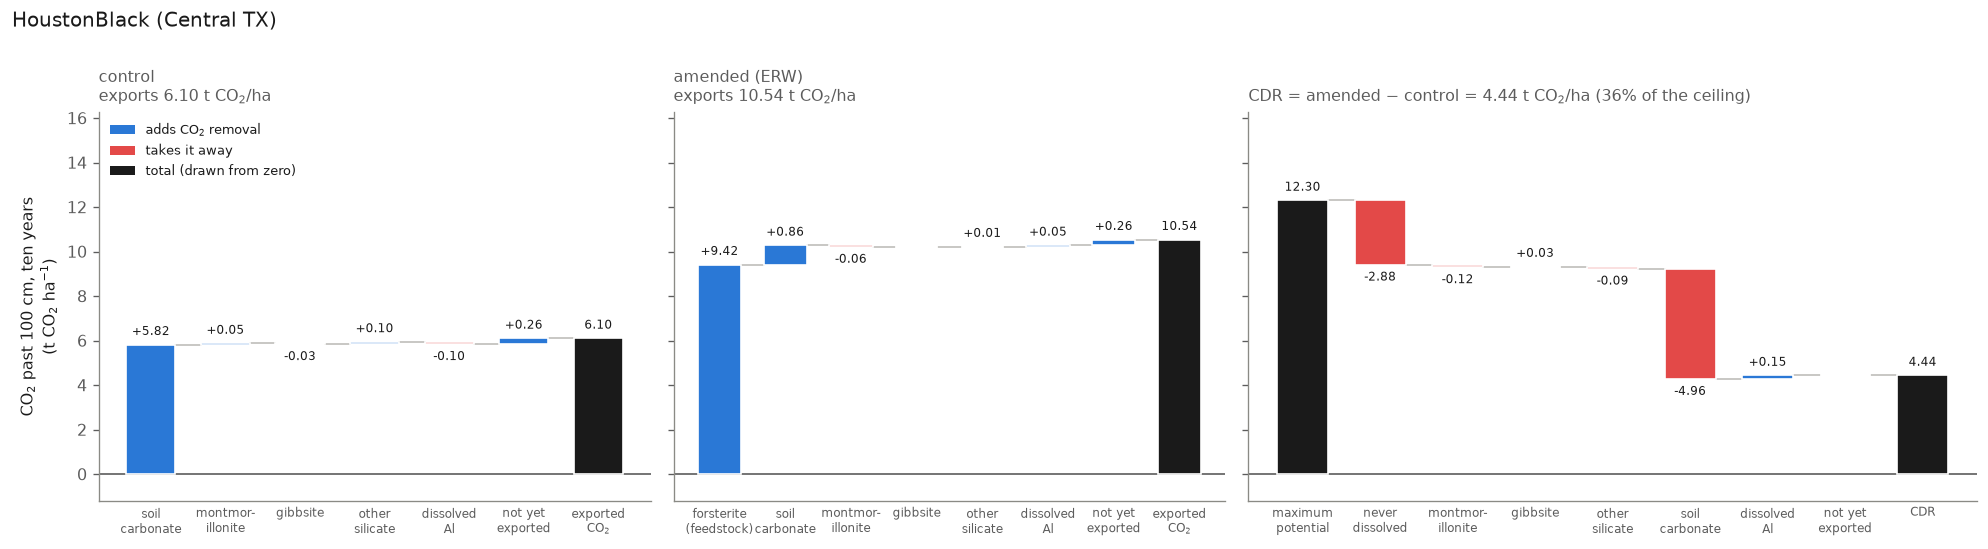

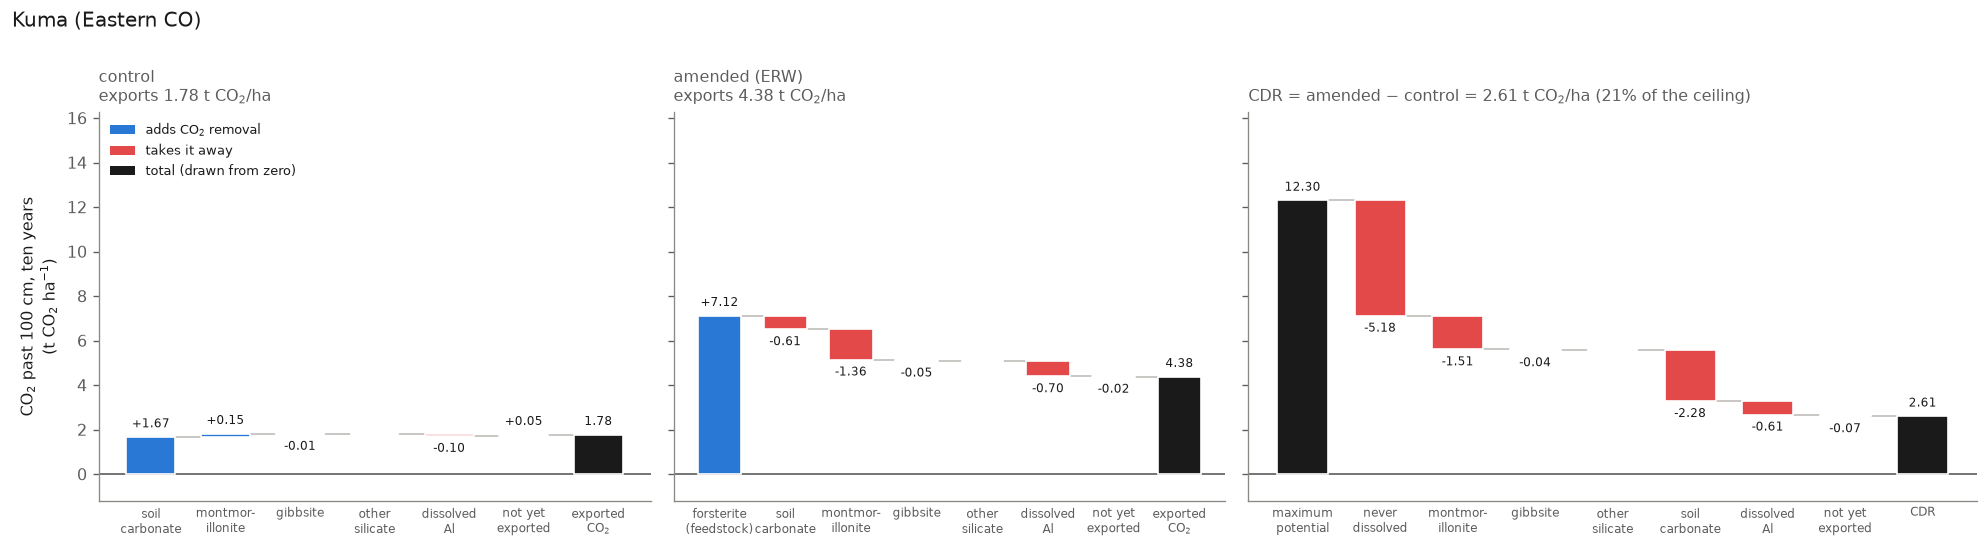

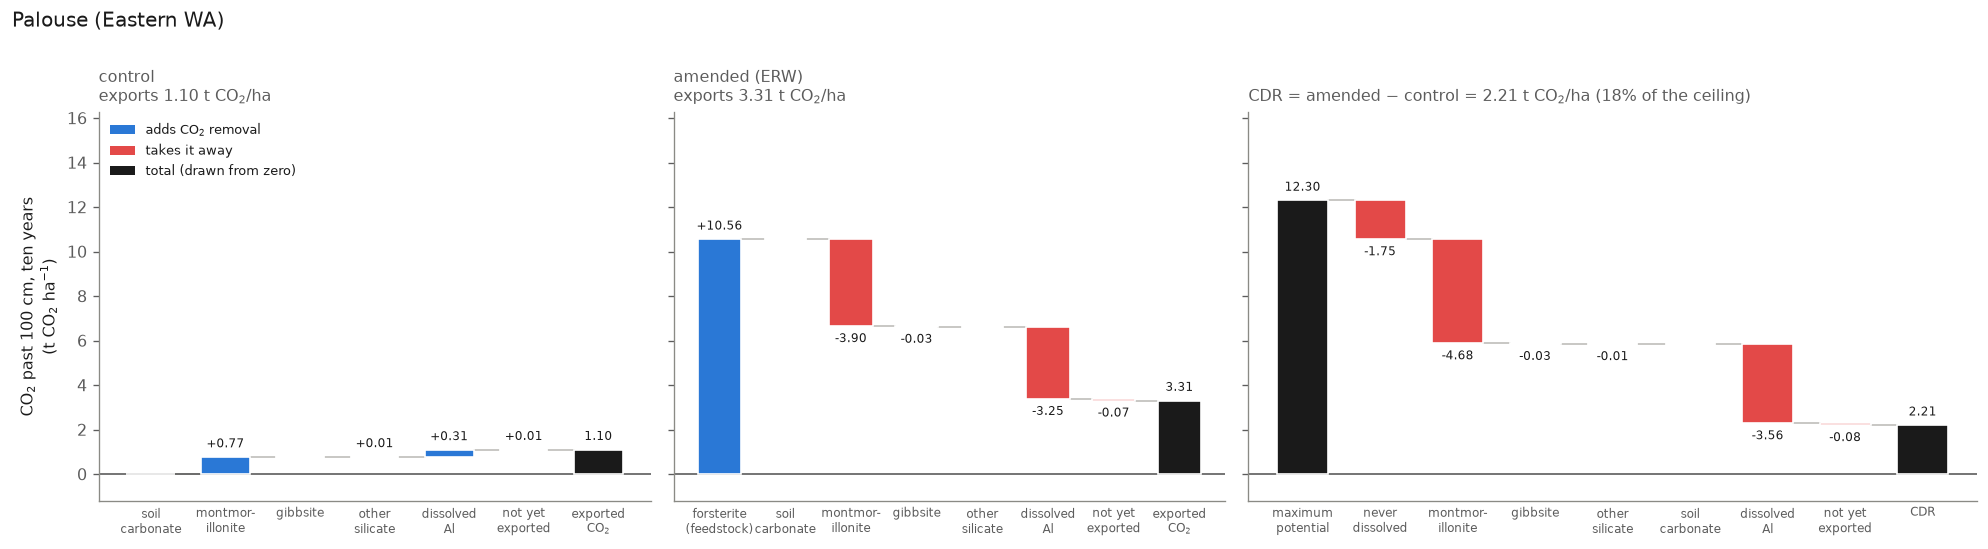

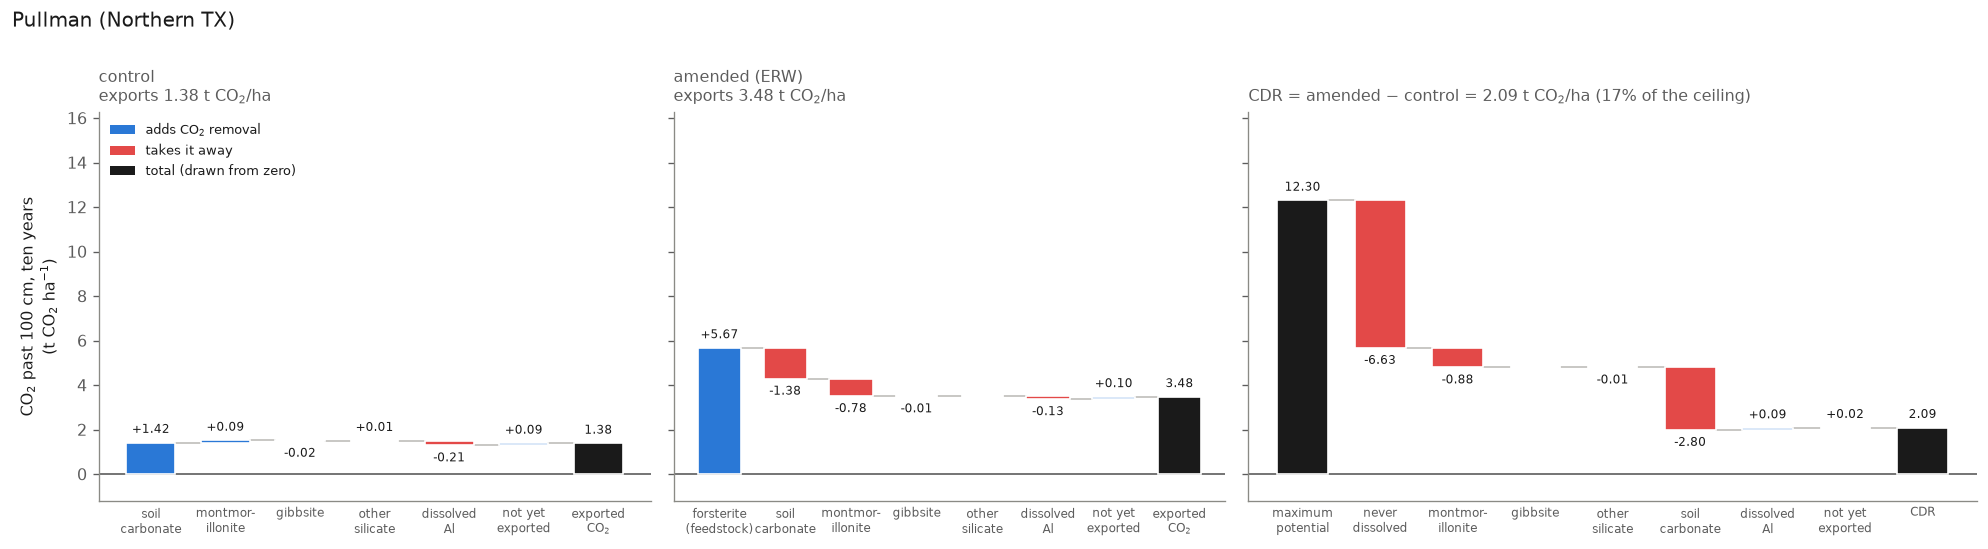

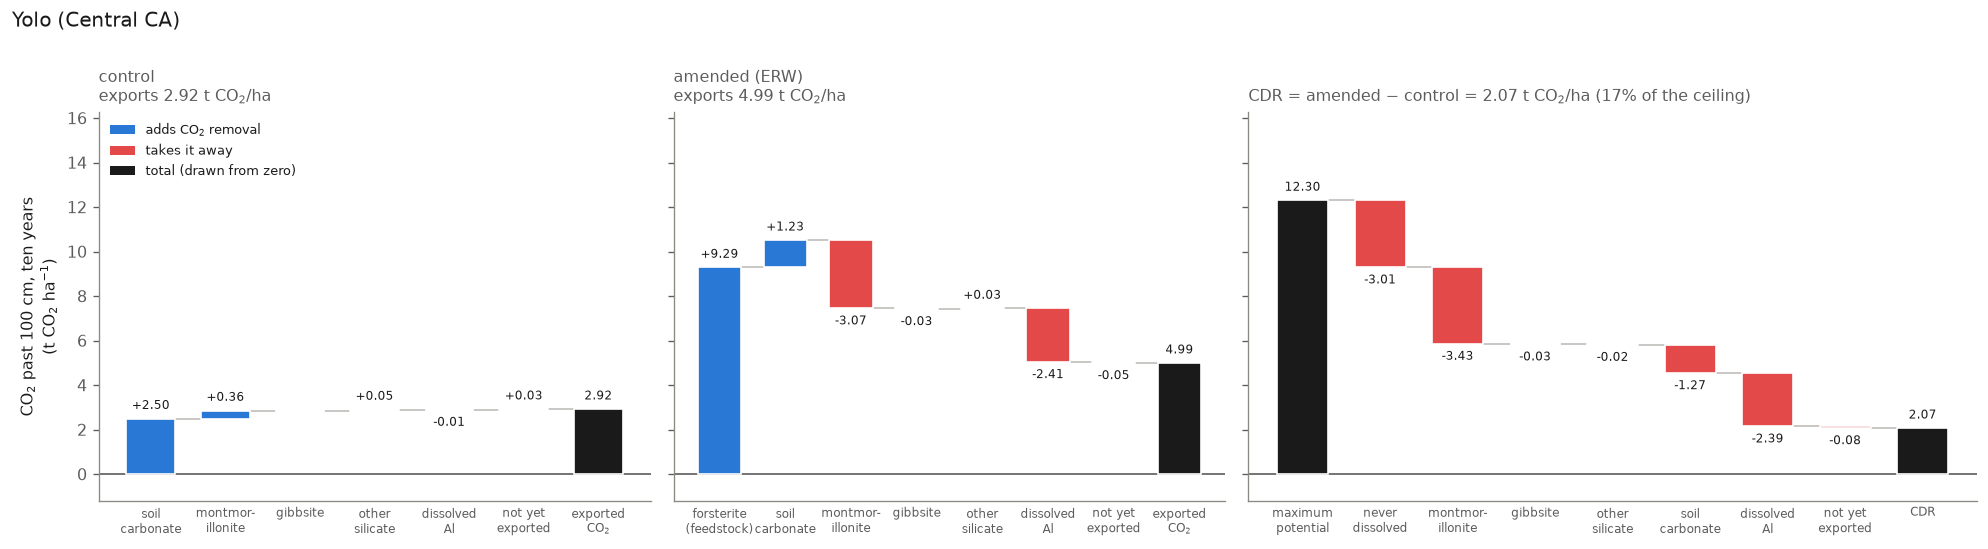

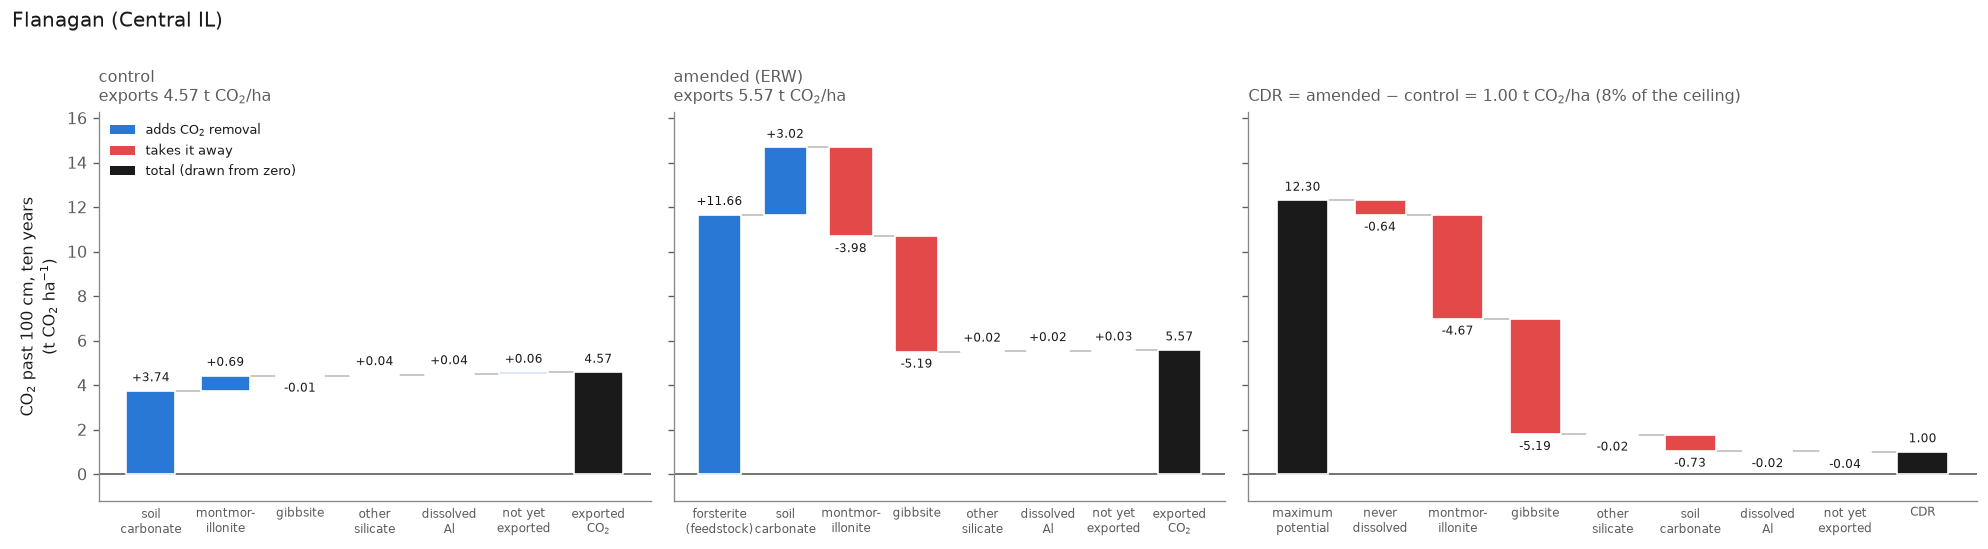

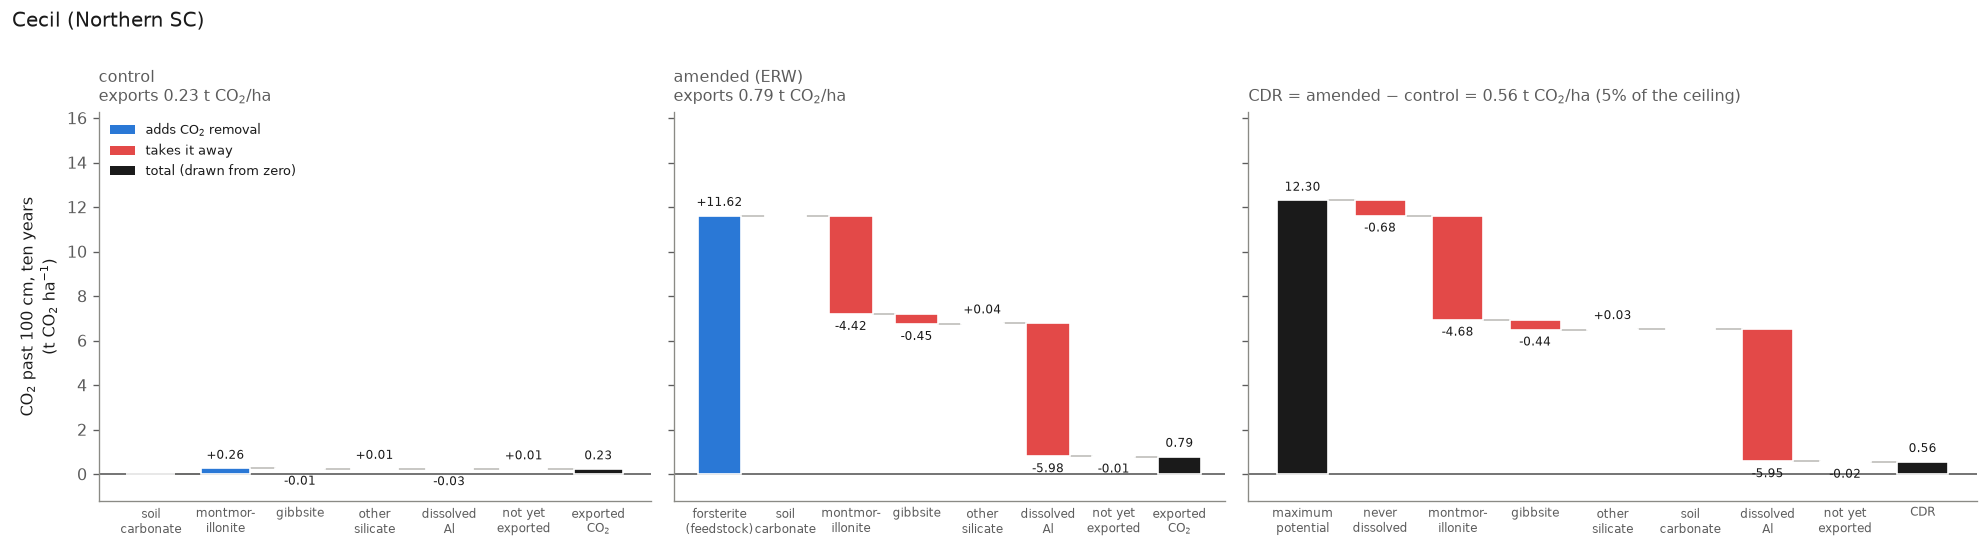

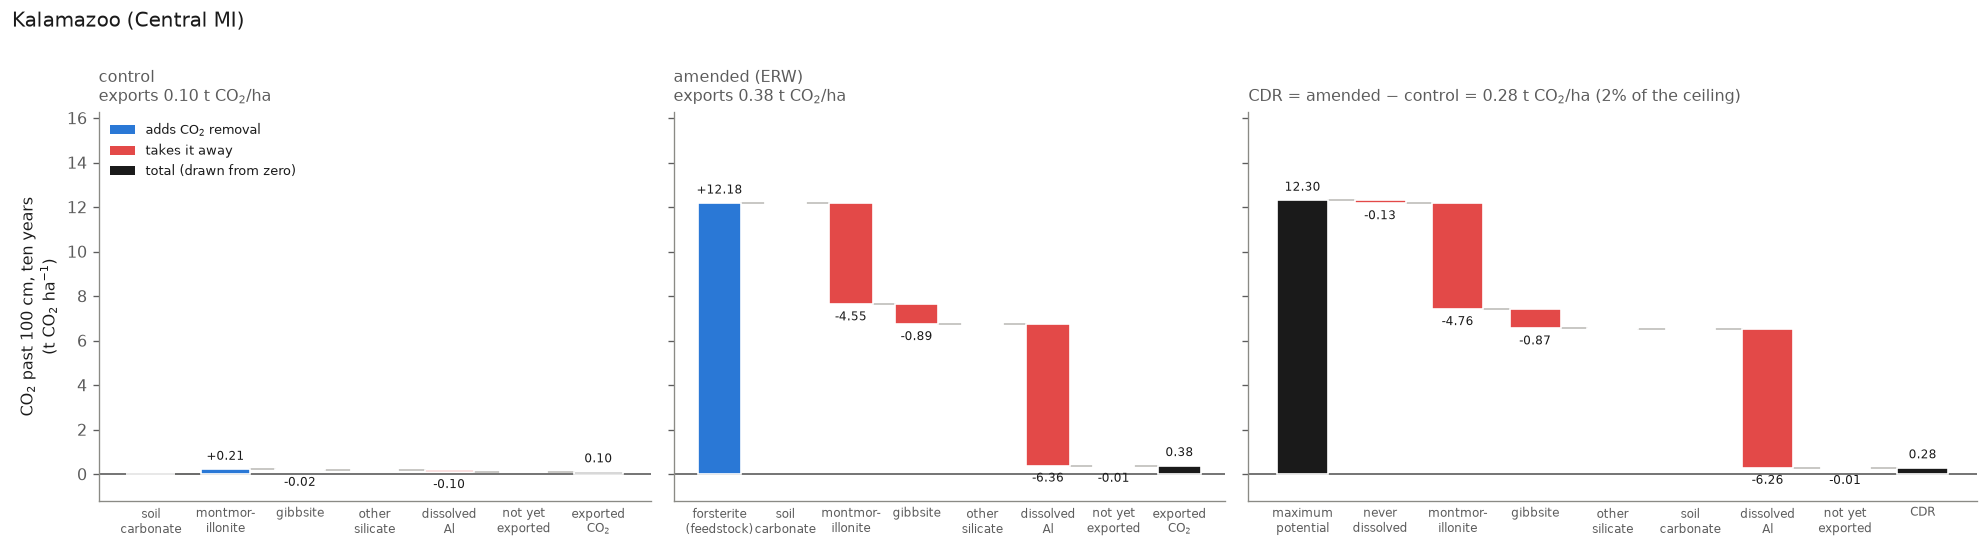

In [12]:
for site in ORDER:
    fig = site_figure(site, ylim=YLIM)
    if SAVE:
        fig.savefig(Path("figures") / f"cdr_decomp_{site}_{CASE}_{PLANE}.png",
                    dpi=300, bbox_inches="tight")
    plt.show()

The left and middle panels are worth reading against each other before the ladder. At
**HoustonBlack** the control alone exports 6.10 t CO₂/ha of carbonate-corrected CO₂ — soil carbonate
weathering that would have happened anyway — and the amended column exports 10.54; the ladder's
`soil carbonate` bar of −4.96 is the amended column's carbonate weathering *falling short of the
control's*, because forsterite alkalinity holds its pore water near calcite saturation and because
the Ca²⁺ it evicted from the exchanger is already there. Nothing was emitted; a background flux was
suppressed.

At **Cecil** the control exports essentially nothing (0.23) and the amended column 0.79. The middle
panel shows why the second number is not 12: of the 11.6 t CO₂/ha the feedstock generated, 4.4 goes
to montmorillonite, 0.5 to gibbsite, and 6.0 walks out of the profile as dissolved aluminium. (The
ladder's montmorillonite bar reads 4.7 rather than 4.4 because the *control* was slowly dissolving
montmorillonite, and CDR is the difference.)

**Pullman** fails first instead of last. Its feedstock bar is only 5.67 — barely half the ceiling —
because its amended zone runs short of CO₂, a mechanism worked out in `tests/PullmanAnomaly.ipynb`.

## 6. All eight together

The left panel is the same eight ladders stacked: the ceiling as a frame, each sink taking a bite,
and what survives marked on top. The right panel names the single largest sink at each site and how
much of the ceiling it took.

In [13]:
# Five sinks worth naming plus an "other" that gathers the two that never exceed 0.1 t CO2/ha.
SINKS = [("feedstock undissolved", ["never dissolved"]),
         ("montmorillonite",       ["montmorillonite"]),
         ("gibbsite",              ["gibbsite"]),
         ("soil carbonate",        ["soil carbonate"]),
         ("dissolved Al",          ["dissolved Al"]),
         ("other",                 ["other silicate", "not yet exported"])]

# Losses are plotted as positive bites out of the ceiling; a term that GAINS CO2 is netted into the
# same bar and shows as a shorter bite, so the stack plus the CDR always equals the ceiling.
BITE = pd.DataFrame({name: -LAD[cols].sum(axis=1) for name, cols in SINKS})
assert np.allclose(BITE.sum(axis=1) + LAD["CDR"], CEILING), "the bites do not sum to the ceiling"
print(f"every site: sinks + CDR = {CEILING:.3f} t CO2/ha, the ceiling\n")

summary = BITE.copy()
summary["CDR"] = LAD["CDR"]
summary["% of ceiling kept"] = 100 * LAD["CDR"] / CEILING
summary["largest sink"] = BITE.idxmax(axis=1)
summary["off the exchanger"] = np.where(
    LEDGER["Al$^{3+}$"] < LEDGER["Ca$^{2+}$"], "Al3+", "Ca2+")
display(summary.loc[ORDER].round(2))

every site: sinks + CDR = 12.304 t CO2/ha, the ceiling



,feedstock undissolved,montmorillonite,gibbsite,soil carbonate,dissolved Al,other,CDR,% of ceiling kept,largest sink,off the exchanger
HoustonBlack,2.88,0.12,-0.03,4.96,-0.15,0.09,4.44,36.06,soil carbonate,Ca2+
Kuma,5.18,1.51,0.04,2.28,0.61,0.08,2.61,21.18,feedstock undissolved,Ca2+
Palouse,1.75,4.68,0.03,-0.00,3.56,0.09,2.21,17.92,montmorillonite,Al3+
Pullman,6.63,0.88,-0.00,2.80,-0.09,-0.01,2.09,17.01,feedstock undissolved,Ca2+
Yolo,3.01,3.43,0.03,1.27,2.39,0.10,2.07,16.80,montmorillonite,Al3+
Flanagan,0.64,4.67,5.19,0.73,0.02,0.06,1.00,8.14,gibbsite,Al3+
Cecil,0.68,4.68,0.44,-0.00,5.95,-0.01,0.56,4.55,dissolved Al,Al3+
Kalamazoo,0.13,4.76,0.87,-0.00,6.26,0.01,0.28,2.27,dissolved Al,Al3+


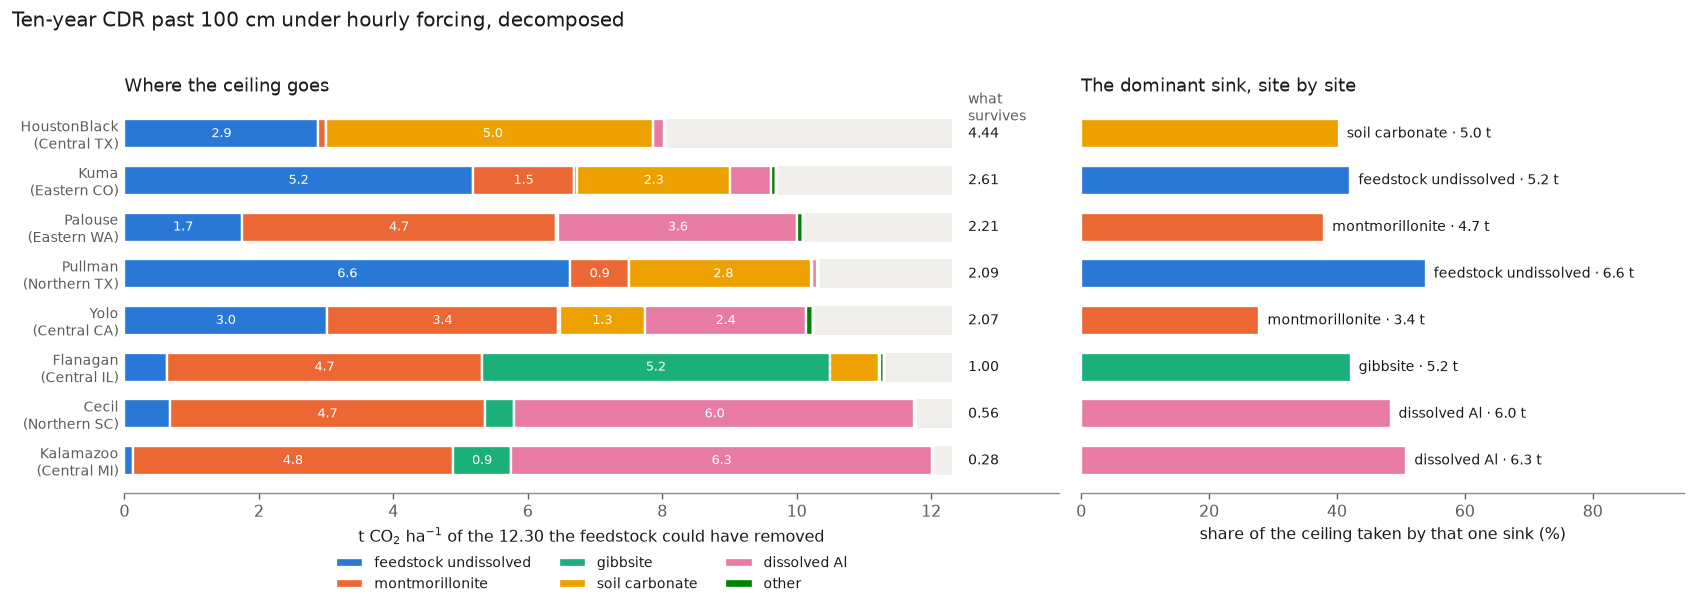

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.0),
                         gridspec_kw={"width_ratios": [1.55, 1]})
y = np.arange(len(ORDER), dtype=float)

# --- left: the ceiling, eaten ------------------------------------------------
# A handful of terms RETURN CO2 rather than taking it (never more than 0.16 t CO2/ha). They are
# stacked last so the bar still ends at the exact total without a negative segment overlapping a
# positive one mid-stack.
ax = axes[0]
ax.barh(y, CEILING, height=0.62, color="#f0efec", edgecolor="none", zorder=1)
left = np.zeros(len(ORDER))
seen = set()
for sign in (+1, -1):
    for name, _ in SINKS:
        w = np.where(np.sign(BITE.loc[ORDER, name].to_numpy()) == sign,
                     BITE.loc[ORDER, name].to_numpy(), 0.0)
        if not np.any(w):
            continue
        ax.barh(y, w, left=left, height=0.62, color=SINK_COLOR[name], edgecolor="white",
                linewidth=1.4, zorder=3, label=None if name in seen else name)
        seen.add(name)
        for yi, wi, li in zip(y, w, left):
            if wi > 0.85:                  # the relief rule: these hues need visible labels
                ax.annotate(f"{wi:.1f}", (li + wi / 2, yi), ha="center", va="center",
                            fontsize=7.8, color="white", zorder=5)
        left = left + w
for yi, s in zip(y, ORDER):
    ax.annotate(f"{LAD.loc[s, 'CDR']:.2f}", (CEILING * 1.02, yi), ha="left", va="center",
                fontsize=8.6, color=INK, zorder=5)
ax.set_yticks(y)
ax.set_yticklabels([f"{s}\n({states_per_site[s]})" for s in ORDER], fontsize=8.6)
ax.invert_yaxis()
ax.set_xlim(0, CEILING * 1.13)
ax.set_xticks(np.arange(0, CEILING + 1, 2))
ax.set_xlabel(f"t CO$_2$ ha$^{{-1}}$ of the {CEILING:.2f} the feedstock could have removed")
ax.annotate("what\nsurvives", (CEILING * 1.02, -0.55), ha="left", va="center", fontsize=8.2,
            color=MUTED)
ax.set_title("Where the ceiling goes", loc="left")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncols=3, fontsize=8.2)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)

# --- right: the single largest sink -----------------------------------------
ax = axes[1]
big = BITE.loc[ORDER].max(axis=1).to_numpy()
who = BITE.loc[ORDER].idxmax(axis=1)
ax.barh(y, 100 * big / CEILING, height=0.62, color=[SINK_COLOR[w] for w in who],
        edgecolor="white", linewidth=1.4, zorder=3)
for yi, b, w in zip(y, big, who):
    ax.annotate(f"  {w} · {b:.1f} t", (100 * b / CEILING, yi), va="center", fontsize=8.4,
                color=INK, zorder=5)
ax.set_yticks(y)
ax.set_yticklabels([])
ax.invert_yaxis()
ax.set_xlim(0, 100 * big.max() / CEILING * 1.75)
ax.set_xlabel("share of the ceiling taken by that one sink (%)")
ax.set_title("The dominant sink, site by site", loc="left")
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)

fig.suptitle(f"Ten-year CDR past {PLANE} cm under {CASE} forcing, decomposed",
             y=1.02, x=0.005, ha="left", fontsize=12)
plt.tight_layout()
if SAVE:
    fig.savefig(Path("figures") / f"cdr_decomp_synthesis_{CASE}_{PLANE}.png",
                dpi=300, bbox_inches="tight")

Three regimes, and they do not overlap — and the `off the exchanger` column in the table above
predicts which one a site is in.

**Aluminium and clay — Cecil, Kalamazoo, Palouse.** No carbonate above the plane, so nothing is
clawed back by the control, and the feedstock dissolves almost completely. It then runs into an
acid, Al-saturated exchange complex: montmorillonite takes 4.7 t CO₂/ha at each of them and
dissolved aluminium another 3.6–6.3. Cecil and Kalamazoo keep 5% and 2% of the ceiling. Palouse
keeps 18% only because less of its aluminium escapes.

**Carbonate — HoustonBlack, Kuma, Pullman, Yolo.** The dominant loss is the control's own carbonate
weathering, which the amendment suppresses by holding the pore water near calcite saturation. They
are four of the top five in absolute terms (2.07–4.44 t CO₂/ha) despite that, because their exchange
complexes are base-saturated and hand back Ca²⁺ rather than Al³⁺. Two of them — Kuma and Pullman —
also leave 42% and 54% of the feedstock undissolved.

**Gibbsite — Flanagan.** The only site where gibbsite is the largest single sink, at 5.19 t CO₂/ha,
and the only site where the displaced aluminium precipitates instead of leaving.

The practical reading: **the ceiling is a poor predictor of the outcome, and the two ways of missing
it are unrelated.** Pullman and Cecil both deliver under a fifth of the ten-year potential for
opposite reasons — Pullman still has 54% of its rock sitting there at ten years, Cecil dissolved 94%
of its and gave the alkalinity away. A field programme that measured only feedstock dissolution
would call Cecil a success and Pullman a failure, and have it backwards on both.

## 7. What this is, and what it is not

**The identity is exact.** Every ladder sums to its own CDR to 10⁻¹⁵ t CO₂/ha, because the
aluminium term closes an alkalinity balance whose other terms are all independently measured. The
CDR being decomposed is the repo's published metric and reproduces it to three decimals.

**The aluminium term is the one that is inferred rather than read off.** §3 identifies it (3.4 eq
per mole of aluminium leaving, r² = 0.995; the Al balance above the plane recovers the whole-domain
exchangeable-Al change) and bounds it (|E| ≤ 0.32 t CO₂/ha in every control, which is the closure
error it also carries). §3b then derives its coefficient from a charge balance rather than fitting
it: 3.00 of the 3.4 is base-cation charge parked on the exchange complex, an identity that closes to
r² = 0.9999, and the remaining ~0.4 is the gap between MIN3P's carbonate alkalinity and the
conservative-ion one. **The acid that exported Al³⁺ makes downstream is deliberately not charged
here** — the alkalinity was already paid for at the exchange site, so charging it again would double
count. It is a cost to whatever water receives that aluminium, and that water is outside the
domain.

**The exchange ledger is not inferred.** §4 is read straight out of MIN3P's own sorbed inventory and
balances to 0.02 eq/m² because the CEC is fixed. Its one approximation is scope: `_o.mss` is
integrated over the whole 4 m domain while the ladder is above the plane. §3's 1:1 check says that
does not matter here — the exchange front is finished well above 1 m — but at a 50 cm plane it
would. The magnesium budget on the same figure is above the plane and carries a closure of at most
1.1 mol/m² against 6–14 released, with the rainfall input cancelling in the ERW − CTRL difference.

**Caveats inherited from the metric**, in full in `MetForcingResolution100cmFront.ipynb` §0b:

1. **It stops at the plane.** Alkalinity that crosses 1 m can still precipitate carbonate or degas
   in the deeper vadose zone, in groundwater, or in a river. This is an upper bound on delivered
   removal — and the dissolved aluminium counted as a loss here may be re-precipitated just below
   the plane, in which case it was a loss anyway, or carried further, in which case it acidifies
   something downstream.
2. **The bicarbonate endpoint is assumed.** On ocean-equilibration timescales carbonate
   compensation returns roughly half the bicarbonate carbon; that convention is deliberately not
   applied.
3. **The carbon attribution is a budget, not a tracer.** No molecule is labelled "from calcite".
   The subtraction is exact as a mass balance over the soil above the plane; carrying it onto the
   exported flux is the §0b assumption.
4. **The secondary-mineral and exchange choices do real work.** Montmorillonite is the largest sink
   at three sites and consumes 6 eq per mole; *which* secondary clay forms is a deck assumption with
   a large lever on the answer. So is the exchange model — a Gaines-Thomas exchanger with
   site-specific CEC and an Al-bearing initial composition, which §4 shows is the single largest
   control on where a site lands.
5. **Respiration is prescribed**, and the counterfactual is modelled rather than measured.
6. **Ten years, one application, one column**, at a single reporting plane under a single met
   forcing. `PLANE` and `CASE` at the top of §0 move both, and the identity closes to machine
   precision at all four planes and all four forcings. The closure error does grow shallower: the
   control-leg bound on `dissolved Al` is 0.32 t CO₂/ha at 100 cm but 0.96 at 50 cm, because that
   plane sits inside the reacting zone rather than below it. §3 prints the bound for whatever plane
   is selected — read it before quoting an aluminium number at 50 cm.
7. **Ten years is short relative to the exchange complex.** §4's finding that most of the feedstock
   magnesium is still adsorbed means the ten-year CDR is not a steady state — the sinks measured
   here are partly the filling of finite pools, not a permanent tax. Nothing in these runs says when
   they fill.

The met-forcing dimension is taken apart with the same ladder in
`tests/CdrDecomposition-MetForcing.ipynb`.